# 🧠 Hybrid Classical–Quantum CNN — Brain Tumour Classification
### COM748 MSc Research Project · MD Meghdad Hossain Akash · Ulster University

| Section | What it does |
|---|---|
| 1 | Install packages |
| 2 | Imports & config |
| 3 | Download dataset |
| 4 | Parse .mat files |
| 5 | Exploratory data analysis |
| 6 | Patient-level splits & DataLoaders |
| 6b | Data-leak proof |
| 7 | EfficientNet-B0 backbone |
| 8 | Classical baselines A & B |
| 9 | Quantum circuit (PennyLane) |
| 10 | Hybrid model |
| 11 | Training loop (with PQC gradient logging) |
| 12 | Evaluation functions |
| 13 | Main experiment (5 seeds × 3 models) |
| 14 | Ablation study (3×3 grid) |
| 15 | Randomised-PQC control |
| 16 | Training curves |
| 16b | PQC gradient norm plot |
| 17 | Confusion matrices (seed 42) |
| 17b | Confusion matrices (seed-averaged) |
| 18 | t-SNE visualisation |
| 18b | ROC curves |
| 19 | Wilcoxon + Cohen's d + RQ answers |
| 20 | Final tables, boxplot & save |

## Section 1 — Install Packages
Run once. Skip if already installed.

In [5]:
import subprocess, sys
packages = [
    'pennylane', 'pennylane-lightning', 'h5py', 'scipy',
    'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'Pillow', 'ipykernel'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All packages installed.')

✅ All packages installed.


## Section 2 — Imports & Configuration

In [6]:
import os, random, warnings, json, time, shutil, zipfile, urllib.request
from pathlib import Path
from collections import defaultdict
from itertools import product

import numpy as np
import pandas as pd
import h5py
from scipy.stats import wilcoxon as _wilcoxon
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

import pennylane as qml

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import warnings as _warn
_warn.filterwarnings('ignore')
sns.set_style('whitegrid')
matplotlib.rcParams.update({'font.size': 11})

# ── Device: auto-detects your GPU ────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    torch.set_float32_matmul_precision('high')
else:
    print('   No GPU — CPU only (training will be slow)')

# ── Output folders ────────────────────────────────────────────────────────────
OUT_DIR = Path('C:/brain_tumour/outputs')
for sub in ['plots', 'checkpoints', 'results']:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)
print(f'📁 Output folder: {OUT_DIR.resolve()}')

# ── All settings in one place ─────────────────────────────────────────────────
CONFIG = {
    'img_size'       : 128,
    'num_classes'    : 3,
    'class_names'    : ['Glioma', 'Meningioma', 'Pituitary'],
    'batch_size'     : 32,
    'epochs'         : 40,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'patience'       : 8,
    'n_qubits'       : 4,
    'n_layers'       : 1,
    # ⚡ TIP: change to [42] for a 30-min smoke test, then restore all 5
    'seeds'          : [42, 7, 13, 99, 2024],
    'ablation_dims'  : [4, 8, 16],
    'ablation_layers': [1, 2, 3],
}
print('⚙️  Config loaded. Seeds:', CONFIG['seeds'])
print('✅ Section 2 complete.')

🖥  Device: cuda
   GPU : NVIDIA GeForce RTX 5050 Laptop GPU
   VRAM: 8.5 GB
📁 Output folder: C:\brain_tumour\outputs
⚙️  Config loaded. Seeds: [42, 7, 13, 99, 2024]
✅ Section 2 complete.


## Section 3 — Download Dataset
Downloads the Figshare brain-tumour MRI dataset (~200 MB total, 4 zip parts).
Already downloaded? It skips automatically.

In [7]:
DATA_DIR = Path('C:/brain_tumour/data')
MAT_DIR  = DATA_DIR / 'mat_files'
DATA_DIR.mkdir(parents=True, exist_ok=True)
MAT_DIR.mkdir(parents=True, exist_ok=True)

FIGSHARE_FILES = {
    'brainTumorDataPublic_1-766.zip'     : 'https://ndownloader.figshare.com/files/3381290',
    'brainTumorDataPublic_767-1532.zip'  : 'https://ndownloader.figshare.com/files/3381296',
    'brainTumorDataPublic_1533-2298.zip' : 'https://ndownloader.figshare.com/files/3381293',
    'brainTumorDataPublic_2299-3064.zip' : 'https://ndownloader.figshare.com/files/3381302',
}

def is_valid_zip(path):
    if not Path(path).exists() or Path(path).stat().st_size < 1000:
        return False
    try:
        with zipfile.ZipFile(path, 'r') as z:
            return z.testzip() is None
    except zipfile.BadZipFile:
        return False

existing = list(MAT_DIR.glob('*.mat'))
if len(existing) >= 3064:
    print(f'✅ {len(existing)} .mat files already present — skipping download.')
else:
    for fname, url in FIGSHARE_FILES.items():
        part = DATA_DIR / fname
        if not is_valid_zip(part):
            print(f'📥 Downloading {fname} ...')
            urllib.request.urlretrieve(url, part)
            if not is_valid_zip(part):
                raise RuntimeError(
                    f'❌ {fname} did not download correctly.\n'
                    f'Download manually from:\n'
                    f'https://figshare.com/articles/dataset/brain_tumor_dataset/1512427'
                )
            print(f'   ✅ Verified {fname}')
        else:
            print(f'✅ {fname} already downloaded.')
        print(f'   📦 Extracting ...')
        with zipfile.ZipFile(part, 'r') as z:
            for member in z.namelist():
                if member.endswith('.mat'):
                    target = MAT_DIR / Path(member).name
                    with z.open(member) as src, open(target, 'wb') as dst:
                        shutil.copyfileobj(src, dst)

total = len(list(MAT_DIR.glob('*.mat')))
print(f'\n✅ Section 3 complete: {total} .mat files ready.')

✅ 3064 .mat files already present — skipping download.

✅ Section 3 complete: 3064 .mat files ready.


## Section 4 — Parse .mat Files
MATLAB HDF5 format. Reads label, patient ID, and image path for all 3,064 slices.

In [8]:
def load_mat_h5(path):
    """Load one .mat file → image (numpy), label (int), patient ID (str)."""
    with h5py.File(str(path), 'r') as f:
        grp     = f['cjdata']
        image   = grp['image'][()].astype(np.float32)
        label   = int(grp['label'][()].flatten()[0])
        pid_raw = grp['PID'][()]
        if pid_raw.dtype.kind in ['u', 'i']:
            pid = ''.join(chr(int(c)) for c in pid_raw.flatten())
        elif pid_raw.dtype.kind == 'S':
            pid = b''.join(pid_raw.flatten()).decode('utf-8')
        else:
            pid = str(pid_raw.item())
    return {'image': image, 'label': label, 'pid': pid.strip()}

# Figshare: 1=meningioma, 2=glioma, 3=pituitary
# Remap to alphabetical: 0=Glioma, 1=Meningioma, 2=Pituitary
LABEL_MAP = {1: 1, 2: 0, 3: 2}

records, failed = [], []
mat_files = sorted(MAT_DIR.glob('*.mat'))
print(f'Parsing {len(mat_files)} .mat files ...')

for mp in mat_files:
    try:
        d = load_mat_h5(mp)
        records.append({'path': str(mp), 'pid': d['pid'], 'label': LABEL_MAP[d['label']]})
    except Exception as e:
        failed.append((mp.name, str(e)))

df = pd.DataFrame(records)
assert len(df) > 0, 'No files parsed — check Section 3 ran correctly.'

print(f'\n✅ Parsed {len(df)} slices from {df["pid"].nunique()} patients ({len(failed)} failed).')
for i, name in enumerate(CONFIG['class_names']):
    print(f'   {i}  {name:12s}: {(df["label"]==i).sum()} slices')
df.head()

Parsing 3064 .mat files ...

✅ Parsed 3064 slices from 233 patients (0 failed).
   0  Glioma      : 1426 slices
   1  Meningioma  : 708 slices
   2  Pituitary   : 930 slices


,path,pid,label
0,C:\brain_tumour\data\mat_files\1.mat,100360,1
1,C:\brain_tumour\data\mat_files\10.mat,101016,1
2,C:\brain_tumour\data\mat_files\100.mat,107494,1
3,C:\brain_tumour\data\mat_files\1000.mat,112649,2
4,C:\brain_tumour\data\mat_files\1001.mat,112649,2


## Section 5 — Exploratory Data Analysis

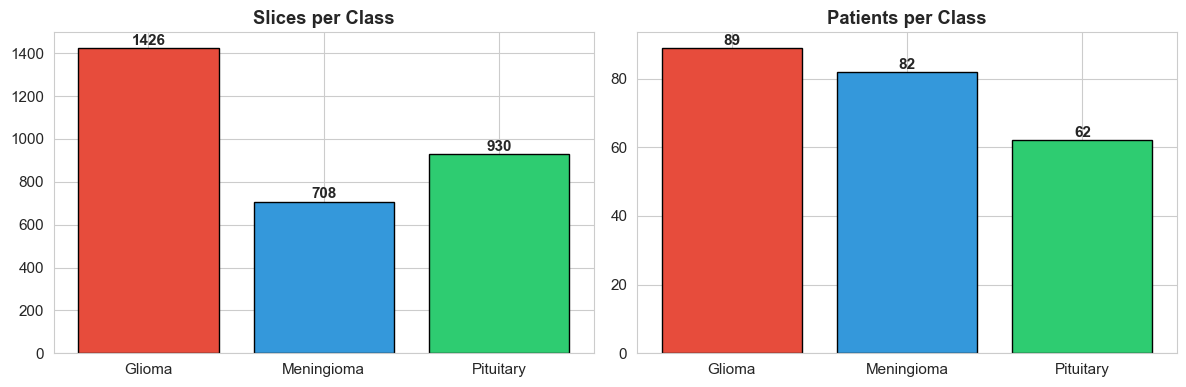

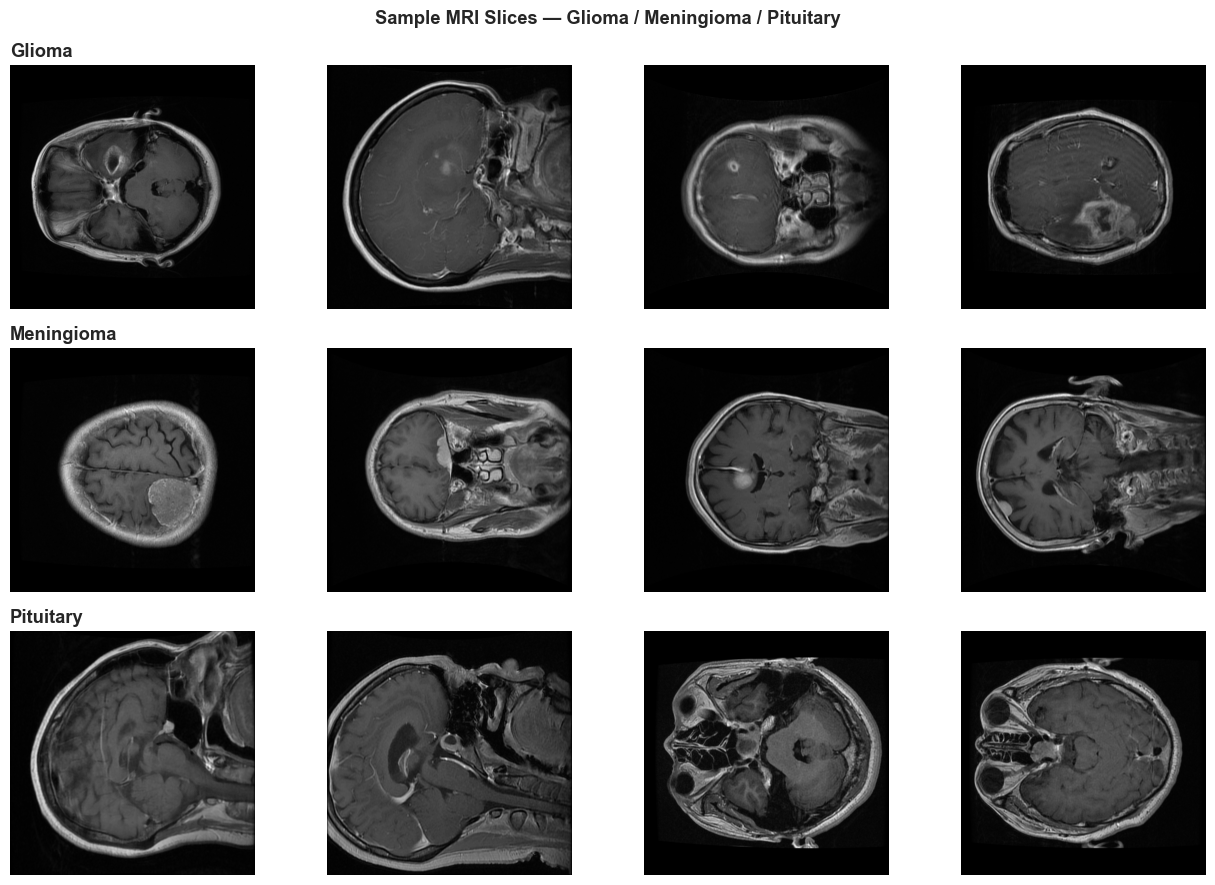

💾 EDA plots saved.


In [9]:
colors = ['#E74C3C', '#3498DB', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
slice_counts   = [(df['label']==i).sum() for i in range(3)]
patient_counts = [df[df['label']==i]['pid'].nunique() for i in range(3)]
for ax, counts, title in [
    (axes[0], slice_counts,   'Slices per Class'),
    (axes[1], patient_counts, 'Patients per Class'),
]:
    ax.bar(CONFIG['class_names'], counts, color=colors, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts)*0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'plots'/'eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
for row_idx, (ci, cname) in enumerate(zip(range(3), CONFIG['class_names'])):
    sample_paths = df[df['label']==ci]['path'].sample(4, random_state=42).tolist()
    for col_idx, p in enumerate(sample_paths):
        d_   = load_mat_h5(p)
        img  = d_['image']
        img  = (img - img.min()) / (img.max() - img.min() + 1e-8)
        axes[row_idx][col_idx].imshow(img, cmap='gray')
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_title(cname, loc='left', fontweight='bold')
plt.suptitle('Sample MRI Slices — Glioma / Meningioma / Pituitary', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'plots'/'eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 EDA plots saved.')

## Section 6 — Patient-Level Splits & DataLoaders

In [10]:
def patient_level_split(df, train_frac=0.70, val_frac=0.15, seed=42):
    rng = np.random.RandomState(seed)
    tr_idx, va_idx, te_idx = [], [], []
    for cls in sorted(df['label'].unique()):
        cdf  = df[df['label'] == cls]
        pids = rng.permutation(cdf['pid'].unique()).tolist()
        n    = len(pids)
        ntr  = int(n * train_frac)
        nva  = int(n * val_frac)
        tp, vp, ep = pids[:ntr], pids[ntr:ntr+nva], pids[ntr+nva:]
        tr_idx += cdf[cdf['pid'].isin(tp)].index.tolist()
        va_idx += cdf[cdf['pid'].isin(vp)].index.tolist()
        te_idx += cdf[cdf['pid'].isin(ep)].index.tolist()
    return tr_idx, va_idx, te_idx

IMG  = CONFIG['img_size']
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG, IMG)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
eval_tf = T.Compose([
    T.Resize((IMG, IMG)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

class BrainMRIDataset(Dataset):
    def __init__(self, subset_df, transform):
        self.records = subset_df.reset_index(drop=True)
        self.tf      = transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        row   = self.records.iloc[idx]
        d_    = load_mat_h5(row['path'])
        img   = d_['image']
        img   = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img_3 = np.stack([img, img, img], axis=2)
        pil   = Image.fromarray((img_3 * 255).astype(np.uint8))
        return self.tf(pil), int(row['label'])

def make_loaders(df, seed=42, batch_size=32):
    tr, va, te = patient_level_split(df, seed=seed)
    ds_tr = BrainMRIDataset(df.loc[tr], train_tf)
    ds_va = BrainMRIDataset(df.loc[va], eval_tf)
    ds_te = BrainMRIDataset(df.loc[te], eval_tf)
    labels = [int(df.loc[i, 'label']) for i in tr]
    counts = np.bincount(labels, minlength=3).astype(float)
    cw     = torch.tensor(1.0 / (counts + 1e-8), dtype=torch.float32)
    cw     = cw / cw.sum() * 3
    mk = lambda ds, shuf: DataLoader(ds, batch_size=batch_size, shuffle=shuf, num_workers=0)
    return mk(ds_tr, True), mk(ds_va, False), mk(ds_te, False), cw

_tr_ld, _, _, _cw = make_loaders(df, 42, CONFIG['batch_size'])
_x, _y = next(iter(_tr_ld))
print(f'\n✅ DataLoaders ready. Batch shape: {tuple(_x.shape)} | Class weights: {_cw.numpy().round(3)}')


✅ DataLoaders ready. Batch shape: (32, 3, 128, 128) | Class weights: [0.669 1.329 1.001]


## Section 6b — Data-Leak Proof Assertion
Verifies zero patient overlap between train / val / test.

In [11]:
_tr, _va, _te = patient_level_split(df, seed=42)
tr_pids = set(df.loc[_tr, 'pid'].unique())
va_pids = set(df.loc[_va, 'pid'].unique())
te_pids = set(df.loc[_te, 'pid'].unique())

tr_va = tr_pids & va_pids
tr_te = tr_pids & te_pids
va_te = va_pids & te_pids

print('🔍 Patient-Level Leakage Audit (seed 42):')
print(f'   Train ∩ Val  = {len(tr_va)} → {"✅ ZERO LEAK" if not tr_va else "❌ LEAK!"}')
print(f'   Train ∩ Test = {len(tr_te)} → {"✅ ZERO LEAK" if not tr_te else "❌ LEAK!"}')
print(f'   Val   ∩ Test = {len(va_te)} → {"✅ ZERO LEAK" if not va_te else "❌ LEAK!"}')
print(f'\n   Train : {len(tr_pids)} patients / {len(_tr)} slices')
print(f'   Val   : {len(va_pids)} patients / {len(_va)} slices')
print(f'   Test  : {len(te_pids)} patients / {len(_te)} slices')
assert not tr_va and not tr_te and not va_te, 'DATA LEAK DETECTED!'
print('\n✅ Zero patient overlap confirmed. Safe to proceed.')

🔍 Patient-Level Leakage Audit (seed 42):
   Train ∩ Val  = 0 → ✅ ZERO LEAK
   Train ∩ Test = 0 → ✅ ZERO LEAK
   Val   ∩ Test = 0 → ✅ ZERO LEAK

   Train : 162 patients / 2161 slices
   Val   : 34 patients / 440 slices
   Test  : 37 patients / 463 slices

✅ Zero patient overlap confirmed. Safe to proceed.


## Section 7 — EfficientNet-B0 Backbone

In [12]:
class Backbone(nn.Module):
    """
    EfficientNet-B0 pretrained on ImageNet — classification head removed.
    Outputs a 1280-dimensional feature vector per image.

    Freezing strategy:
      Frozen   : features[0-5]  = MBConv blocks 1-6  (low-level, reuse ImageNet)
      Trainable: features[6-8]  = MBConv blocks 7-9  (high-level, fine-tune for MRI)
    """
    def __init__(self, freeze_early=True):
        super().__init__()
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.features    = base.features
        self.avgpool     = base.avgpool
        self.feature_dim = 1280

        if freeze_early:
            for p in self.features.parameters():
                p.requires_grad = False
            for blk_idx in [6, 7, 8]:
                for p in self.features[blk_idx].parameters():
                    p.requires_grad = True

        frozen    = sum(p.numel() for p in self.features.parameters() if not p.requires_grad)
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'   Backbone: {frozen:,} frozen | {trainable:,} trainable params')
        print('   Frozen:    features[0-5]  (MBConv blocks 1-6)')
        print('   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool')

    def forward(self, x):
        return self.avgpool(self.features(x)).flatten(1)

_bb  = Backbone().to(DEVICE)
_out = _bb(torch.randn(2, 3, 128, 128).to(DEVICE))
print(f'\n✅ Backbone: input (2,3,128,128) → output {tuple(_out.shape)}')
del _bb, _out

   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool

✅ Backbone: input (2,3,128,128) → output (2, 1280)


## Section 8 — Classical Baselines A & B

In [13]:
class ClassicalA(nn.Module):
    """Baseline A: EfficientNet-B0 + full-capacity dense head."""
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = Backbone()
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, 256), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.head(self.backbone(x))


class ClassicalB(nn.Module):
    """Baseline B: EfficientNet-B0 + parameter-matched MLP.
    Matches the hybrid model's trainable-parameter count exactly."""
    def __init__(self, num_classes=3, proj_dim=4):
        super().__init__()
        self.backbone = Backbone()
        hidden = max(proj_dim * 2, 8)
        self.head = nn.Sequential(
            nn.Linear(1280, proj_dim), nn.ReLU(),
            nn.Linear(proj_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )
    def forward(self, x):
        return self.head(self.backbone(x))

print('✅ Classical baselines A & B defined.')

✅ Classical baselines A & B defined.


## Section 9 — Quantum Circuit (PennyLane)
Angle encoding → RZ/RY rotations + CNOT ring → Pauli-Z measurement.

In [14]:
def make_quantum_layer(n_qubits, n_layers):
    """
    Build a PennyLane variational circuit and wrap as a PyTorch layer.
    Encoding : RY(x_i) on qubit i
    Variational: d layers of [RZ(θ), RY(θ), CNOT ring]
    Measurement: Pauli-Z expectation on each qubit
    PQC params  = n_layers × n_qubits × 2
    """
    dev = qml.device('default.qubit', wires=n_qubits)

    @qml.qnode(dev, interface='torch', diff_method='backprop')
    def circuit(inputs, weights):
        # Angle encoding
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        # Variational blocks
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RZ(weights[layer, q, 0], wires=q)
                qml.RY(weights[layer, q, 1], wires=q)
            for q in range(n_qubits):
                qml.CNOT(wires=[q, (q + 1) % n_qubits])
        # Measurement
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {'weights': (n_layers, n_qubits, 2)}
    return qml.qnn.TorchLayer(circuit, weight_shapes)

# Quick sanity check
_ql  = make_quantum_layer(4, 1)
_out = _ql(torch.randn(4))
print(f'✅ Quantum layer: input (4,) → output {tuple(_out.shape)}')
print(f'   PQC params: {sum(p.numel() for p in _ql.parameters())} = n_layers × n_qubits × 2')
del _ql, _out

✅ Quantum layer: input (4,) → output (4,)
   PQC params: 8 = n_layers × n_qubits × 2


## Section 10 — Hybrid Model
Backbone → Projection (Linear+Tanh) → PQC → Output layer.

In [15]:
class HybridModel(nn.Module):
    """
    Full hybrid pipeline: EfficientNet-B0 + projection + PQC + output.
    random_pqc=True  →  freeze quantum weights (frozen-PQC control condition).
    """
    def __init__(self, n_qubits=4, n_layers=1, num_classes=3, random_pqc=False):
        super().__init__()
        self.n_qubits      = n_qubits
        self.backbone      = Backbone()
        self.projection    = nn.Sequential(
            nn.Linear(1280, n_qubits),
            nn.Tanh()   # bounds values to [-1,1] — required for angle encoding
        )
        self.quantum_layer = make_quantum_layer(n_qubits, n_layers)
        if random_pqc:
            # Freeze: only backbone + projection + output layer train
            for p in self.quantum_layer.parameters():
                p.requires_grad = False
        self.output_layer = nn.Linear(n_qubits, num_classes)

    def forward(self, x):
        feats = self.backbone(x)          # (B, 1280)
        proj  = self.projection(feats)    # (B, n_qubits)
        # Process each sample through the quantum layer
        q_out = torch.stack(
            [self.quantum_layer(proj[i]) for i in range(proj.shape[0])]
        )                                  # (B, n_qubits)
        return self.output_layer(q_out)   # (B, num_classes)

# Quick sanity check
_hm = HybridModel(4, 1).to(DEVICE)
with torch.no_grad():
    _out = _hm(torch.randn(2, 3, 128, 128).to(DEVICE))
print(f'✅ Hybrid model: input (2,3,128,128) → output {tuple(_out.shape)}')
del _hm, _out

   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
✅ Hybrid model: input (2,3,128,128) → output (2, 3)


## Section 11 — Training Loop
Includes PQC gradient norm logging so we can see if quantum parameters are actually training.

In [16]:
def set_seed(seed):
    """Fix ALL random sources for complete reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)


def train_model(model, tr_loader, va_loader, class_weights,
                epochs=40, lr=1e-3, wd=1e-4, patience=8, verbose=True):
    """
    Trains any model. Returns (history_dict, best_state_dict).
    History contains: train_loss, val_loss, train_acc, val_acc, val_f1,
                      pqc_grad_norm (0.0 for classical models).
    """
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=wd
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )
    hist       = defaultdict(list)
    best_f1    = -1.0
    best_state = None
    wait       = 0

    for ep in range(1, epochs + 1):
        # ── Training ──────────────────────────────────────────────────────────
        model.train()
        tl = tc = tn = 0
        epoch_pqc_grads = []

        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()

            # ── PQC gradient norm (new) ──────────────────────────────────────
            if hasattr(model, 'quantum_layer'):
                pqc_grad_sq = sum(
                    p.grad.norm().item() ** 2
                    for p in model.quantum_layer.parameters()
                    if p.grad is not None
                )
                epoch_pqc_grads.append(pqc_grad_sq ** 0.5)
            # ────────────────────────────────────────────────────────────────

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl += loss.item() * xb.size(0)
            tc += (out.argmax(1) == yb).sum().item()
            tn += xb.size(0)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        vl = vc = vn = 0
        all_p, all_y = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out  = model(xb)
                loss = criterion(out, yb)
                vl += loss.item() * xb.size(0)
                vc += (out.argmax(1) == yb).sum().item()
                vn += xb.size(0)
                all_p += out.argmax(1).cpu().tolist()
                all_y += yb.cpu().tolist()

        vf1 = f1_score(all_y, all_p, average='macro', zero_division=0)
        hist['train_loss'].append(tl / tn)
        hist['val_loss'].append(vl / vn)
        hist['train_acc'].append(tc / tn)
        hist['val_acc'].append(vc / vn)
        hist['val_f1'].append(vf1)
        # Average PQC grad norm for this epoch (0 for classical models)
        hist['pqc_grad_norm'].append(
            float(np.mean(epoch_pqc_grads)) if epoch_pqc_grads else 0.0
        )
        scheduler.step(vf1)

        if vf1 > best_f1:
            best_f1    = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f'   Early stop at epoch {ep} | best val F1={best_f1:.4f}')
                break

        if verbose and ep % 5 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            pqc_g  = hist['pqc_grad_norm'][-1]
            pqc_s  = f' | PQC_grad={pqc_g:.5f}' if pqc_g > 0 else ''
            print(f'   ep {ep:3d} | train={tc/tn:.4f} | val={vc/vn:.4f} | F1={vf1:.4f} | lr={lr_now:.2e}{pqc_s}')

    return dict(hist), best_state

print('✅ Training loop defined (with PQC gradient norm logging).')

✅ Training loop defined (with PQC gradient norm logging).


## Section 12 — Evaluation Functions

In [17]:
def evaluate_model(model, loader):
    """
    Evaluate on a DataLoader.
    Returns dict: accuracy, macro_f1, f1_per_class, precision, recall,
                  predictions (array), ground_truth (array).
    """
    model.eval()
    model.to(DEVICE)
    all_p, all_y = [], []
    with torch.no_grad():
        for xb, yb in loader:
            all_p += model(xb.to(DEVICE)).argmax(1).cpu().tolist()
            all_y += yb.tolist()
    P, Y = np.array(all_p), np.array(all_y)
    return {
        'accuracy'     : accuracy_score(Y, P),
        'macro_f1'     : f1_score(Y, P, average='macro', zero_division=0),
        'precision'    : precision_score(Y, P, average=None, zero_division=0).tolist(),
        'recall'       : recall_score   (Y, P, average=None, zero_division=0).tolist(),
        'f1_per_class' : f1_score       (Y, P, average=None, zero_division=0).tolist(),
        'predictions'  : P,
        'ground_truth' : Y,
    }


def print_results(r, name=''):
    print(f'\n{"─"*52}')
    print(f'  {name}')
    print(f'  Accuracy : {r["accuracy"]*100:.2f}%  |  Macro F1 : {r["macro_f1"]*100:.2f}%')
    print(f'  {"Class":13s} {"Prec":>6} {"Rec":>6} {"F1":>6}')
    for i, n in enumerate(CONFIG['class_names']):
        print(f'  {n:13s} {r["precision"][i]*100:>5.1f}  '
              f'{r["recall"][i]*100:>5.1f}  {r["f1_per_class"][i]*100:>5.1f}')

print('✅ Evaluation functions defined.')

✅ Evaluation functions defined.


## Section 13 — Main Experiment (5 Seeds × 3 Models)
Trains Baseline A, Baseline B, and Hybrid across 5 seeds.


In [42]:
SEEDS = CONFIG['seeds']
NQ, NL = CONFIG['n_qubits'], CONFIG['n_layers']
E, LR, WD, PAT, BS = (
    CONFIG['epochs'], CONFIG['lr'],
    CONFIG['weight_decay'], CONFIG['patience'],
    CONFIG['batch_size']
)

all_results   = {'baseline_a': {}, 'baseline_b': {}, 'hybrid': {}}
all_histories = {'baseline_a': {}, 'baseline_b': {}, 'hybrid': {}}

model_builders = {
    'baseline_a': lambda: ClassicalA(3),
    'baseline_b': lambda: ClassicalB(3, NQ),
    'hybrid'    : lambda: HybridModel(NQ, NL, 3),
}

t_start = time.time()

for seed in SEEDS:
    print(f'\n{"="*55}  SEED {seed}  {"="*55}')
    set_seed(seed)
    tr, va, te, cw = make_loaders(df, seed=seed, batch_size=BS)

    for key, build in model_builders.items():
        ckpt_path = OUT_DIR / 'checkpoints' / f'{key}_seed{seed}.pt'

        if ckpt_path.exists():
            print(f'\n  ✅ {key} seed={seed} — checkpoint found, loading.')
            model = build().to(DEVICE)
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
            res = evaluate_model(model, te)
            all_results[key][seed]   = res
            # No gradient history when loading from checkpoint
            all_histories[key][seed] = {
                'train_loss': [], 'val_loss': [],
                'train_acc' : [], 'val_acc' : [],
                'val_f1'    : [], 'pqc_grad_norm': []
            }
            print(f'     acc={res["accuracy"]*100:.2f}%  F1={res["macro_f1"]*100:.2f}%')
        else:
            print(f'\n  ▶ Training {key} seed={seed} ...')
            set_seed(seed)
            model = build().to(DEVICE)
            hist, state = train_model(model, tr, va, cw, E, LR, WD, PAT, verbose=True)
            model.load_state_dict(state)
            torch.save(state, ckpt_path)
            print(f'  💾 Saved: {ckpt_path.name}')
            res = evaluate_model(model, te)
            all_results[key][seed]   = res
            all_histories[key][seed] = hist
            print_results(res, f'{key}  seed={seed}')

elapsed = (time.time() - t_start) / 60
print(f'\n\n✅ Section 13 complete in {elapsed:.1f} min.')


=======================================================  SEED 42  =======================================================

  ▶ Training baseline_a seed=42 ...
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   ep   5 | train=0.9149 | val=0.8705 | F1=0.8623 | lr=1.00e-03
   ep  10 | train=0.9431 | val=0.8705 | F1=0.8502 | lr=1.00e-03
   Early stop at epoch 15 | best val F1=0.8988
  💾 Saved: baseline_a_seed42.pt

────────────────────────────────────────────────────
  baseline_a  seed=42
  Accuracy : 92.01%  |  Macro F1 : 91.20%
  Class           Prec    Rec     F1
  Glioma         91.1   95.2   93.1
  Meningioma     89.7   78.4   83.7
  Pituitary      95.3   98.4   96.9

  ▶ Training baseline_b seed=42 ...
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   

## Section 14 — Ablation Study (3×3 Grid)
9 circuit configs: projection dim ∈ {4,8,16} × depth ∈ {1,2,3}. Exploratory, single seed 42.

In [19]:
ablation_results = {}
set_seed(42)
tr_a, va_a, te_a, cw_a = make_loaders(df, seed=42, batch_size=BS)

print('🔬 Ablation: 9 configurations (seed 42 only — exploratory)')
print(f'{"Dim":>5} {"Depth":>6} {"PQC params":>11} {"Acc %":>8} {"F1 %":>8}')

for dim, nl in product(CONFIG['ablation_dims'], CONFIG['ablation_layers']):
    abl_path = OUT_DIR / 'checkpoints' / f'ablation_dim{dim}_depth{nl}.pt'

    if abl_path.exists():
        m   = HybridModel(dim, nl, 3).to(DEVICE)
        m.load_state_dict(torch.load(abl_path, map_location=DEVICE))
        r   = evaluate_model(m, te_a)
        npq = sum(p.numel() for p in m.quantum_layer.parameters())
    else:
        set_seed(42)
        m   = HybridModel(dim, nl, 3).to(DEVICE)
        npq = sum(p.numel() for p in m.quantum_layer.parameters())
        _, state = train_model(m, tr_a, va_a, cw_a, E, LR, WD, PAT, verbose=False)
        m.load_state_dict(state)
        torch.save(state, abl_path)
        r = evaluate_model(m, te_a)

    ablation_results[(dim, nl)] = {
        'accuracy'    : r['accuracy'],
        'macro_f1'    : r['macro_f1'],
        'f1_per_class': r['f1_per_class'],
        'pqc_params'  : npq,
    }
    print(f'{dim:>5} {nl:>6} {npq:>11}  {r["accuracy"]*100:>7.2f}  {r["macro_f1"]*100:>7.2f}')

print('\n✅ Ablation complete.')

🔬 Ablation: 9 configurations (seed 42 only — exploratory)
  Dim  Depth  PQC params    Acc %     F1 %
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    4      1           8    91.14    90.42
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    4      2          16    92.22    91.87
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    4      3          24    87.47    86.29
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    8      1          16    86.39    85.99
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:

## Section 15 — Frozen-PQC Control
Quantum weights frozen at random init — tests whether *training* the PQC matters.

In [20]:
random_pqc_results = {}
print('🎲 Frozen-PQC control (quantum weights frozen at random init):')
print(f'{"Seed":>6} {"Acc %":>8} {"Macro F1 %":>11} {"Glioma":>8} {"Mening.":>8} {"Pituit.":>8}')

for seed in SEEDS:
    rnd_path = OUT_DIR / 'checkpoints' / f'random_pqc_seed{seed}.pt'
    set_seed(seed)
    tr, va, te, cw = make_loaders(df, seed=seed, batch_size=BS)

    if rnd_path.exists():
        m = HybridModel(NQ, NL, 3, random_pqc=True).to(DEVICE)
        m.load_state_dict(torch.load(rnd_path, map_location=DEVICE))
    else:
        m = HybridModel(NQ, NL, 3, random_pqc=True).to(DEVICE)
        _, state = train_model(m, tr, va, cw, E, LR, WD, PAT, verbose=False)
        m.load_state_dict(state)
        torch.save(state, rnd_path)

    r = evaluate_model(m, te)
    random_pqc_results[seed] = r
    g, mn, pt = r['f1_per_class']
    print(f'{seed:>6} {r["accuracy"]*100:>7.2f}  {r["macro_f1"]*100:>10.2f}  '
          f'{g*100:>7.2f}  {mn*100:>7.2f}  {pt*100:>7.2f}')

print('\n✅ Frozen-PQC control complete.')

🎲 Frozen-PQC control (quantum weights frozen at random init):
  Seed    Acc %  Macro F1 %   Glioma  Mening.  Pituit.
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    42   93.09       92.28    94.71    86.38    95.75
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
     7   89.32       88.28    91.97    80.61    92.27
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    13   93.12       92.99    91.69    89.47    97.82
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    99   86.14       85.38    87.44    74.38    94.33
   Back

## Section 16 — Training Curves
Shown for seed 42. Only available when trained fresh in this session (not when loaded from checkpoints).

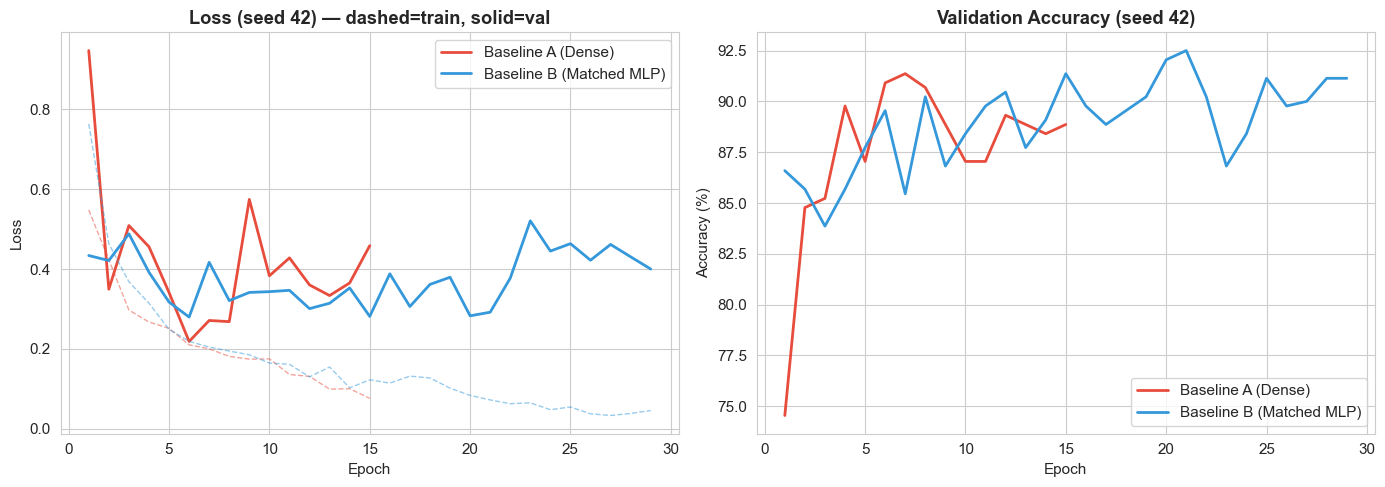

💾 Saved training_curves.png


In [43]:
RS = 42
model_style = {
    'baseline_a': ('Baseline A (Dense)',       '#E74C3C'),
    'baseline_b': ('Baseline B (Matched MLP)', '#3498DB'),
    'hybrid'    : ('Hybrid (PQC)',             '#2ECC71'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
any_history = False

for key, (lab, col) in model_style.items():
    h = all_histories[key].get(RS, {})
    if not h.get('train_loss'):
        continue
    any_history = True
    ep = range(1, len(h['train_loss']) + 1)
    axes[0].plot(ep, h['train_loss'], '--', color=col, alpha=0.5, linewidth=1)
    axes[0].plot(ep, h['val_loss'],   '-',  color=col, label=lab, linewidth=2)
    axes[1].plot(ep, [a*100 for a in h['val_acc']], '-', color=col, label=lab, linewidth=2)

if any_history:
    axes[0].set_title(f'Loss (seed {RS}) — dashed=train, solid=val', fontweight='bold')
    axes[1].set_title(f'Validation Accuracy (seed {RS})', fontweight='bold')
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.legend()
    axes[0].set_ylabel('Loss')
    axes[1].set_ylabel('Accuracy (%)')
    plt.tight_layout()
    plt.savefig(OUT_DIR/'plots'/'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Saved training_curves.png')
else:
    print('ℹ️  No training history — models were loaded from checkpoints.')
    print('   Delete checkpoints and re-run Section 13 to get fresh history.')

## Section 16b — PQC Gradient Norm During Training ⭐ NEW
Shows whether the quantum parameters actually received gradient signal.
- Line **above** red dashed → gradients arrived, training happened but still didn't help (stronger finding)
- Line **below** red dashed → barren plateau — parameters barely moved (trainability failed)

In [44]:
RS = 42
h = all_histories['hybrid'].get(RS, {})

if h.get('pqc_grad_norm') and any(v > 0 for v in h['pqc_grad_norm']):
    grad_norms = h['pqc_grad_norm']
    ep = range(1, len(grad_norms) + 1)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ep, grad_norms, color='#2ECC71', linewidth=2, label='PQC gradient norm (per epoch)')
    ax.axhline(1e-3, color='red', linestyle='--', linewidth=1.5,
               label='Vanishing threshold (1e-3)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gradient Norm (log scale)')
    ax.set_title(f'PQC Parameter Gradient Norms During Training (seed {RS})',
                 fontweight='bold')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, which='both', alpha=0.4)
    plt.tight_layout()
    plt.savefig(OUT_DIR/'plots'/'pqc_grad_norms.png', dpi=150, bbox_inches='tight')
    plt.show()

    avg_norm = float(np.mean(grad_norms))
    min_norm = float(np.min(grad_norms))
    print(f'Mean PQC gradient norm : {avg_norm:.6f}')
    print(f'Min  PQC gradient norm : {min_norm:.6f}')
    print()
    if avg_norm < 1e-3:
        print('⚠️  VANISHING GRADIENTS (barren plateau)')
        print('   The quantum parameters received near-zero gradient throughout training.')
        print('   This means the PQC was effectively untrainable at this scale.')
        print('   → Paper interpretation: training failed due to barren plateaus.')
    else:
        print('✅ HEALTHY GRADIENTS')
        print('   The quantum parameters received non-trivial gradient signal.')
        print('   Training happened, but it still produced no benefit over the frozen control.')
        print('   → Paper interpretation: quantum training is not the operative mechanism.')
else:
    print('ℹ️  No PQC gradient history found for seed 42.')
    print('   This happens when models were loaded from checkpoints (no fresh training).')
    print('   To collect gradient data: delete hybrid checkpoints and re-run Section 13.')
    print()
    print('   Command to delete hybrid checkpoints (run in Command Prompt):')
    print('   del C:\\brain_tumour\\outputs\\checkpoints\\hybrid_seed*.pt')

ℹ️  No PQC gradient history found for seed 42.
   This happens when models were loaded from checkpoints (no fresh training).
   To collect gradient data: delete hybrid checkpoints and re-run Section 13.

   Command to delete hybrid checkpoints (run in Command Prompt):
   del C:\brain_tumour\outputs\checkpoints\hybrid_seed*.pt


## Section 17 — Confusion Matrices (Seed 42 Only)

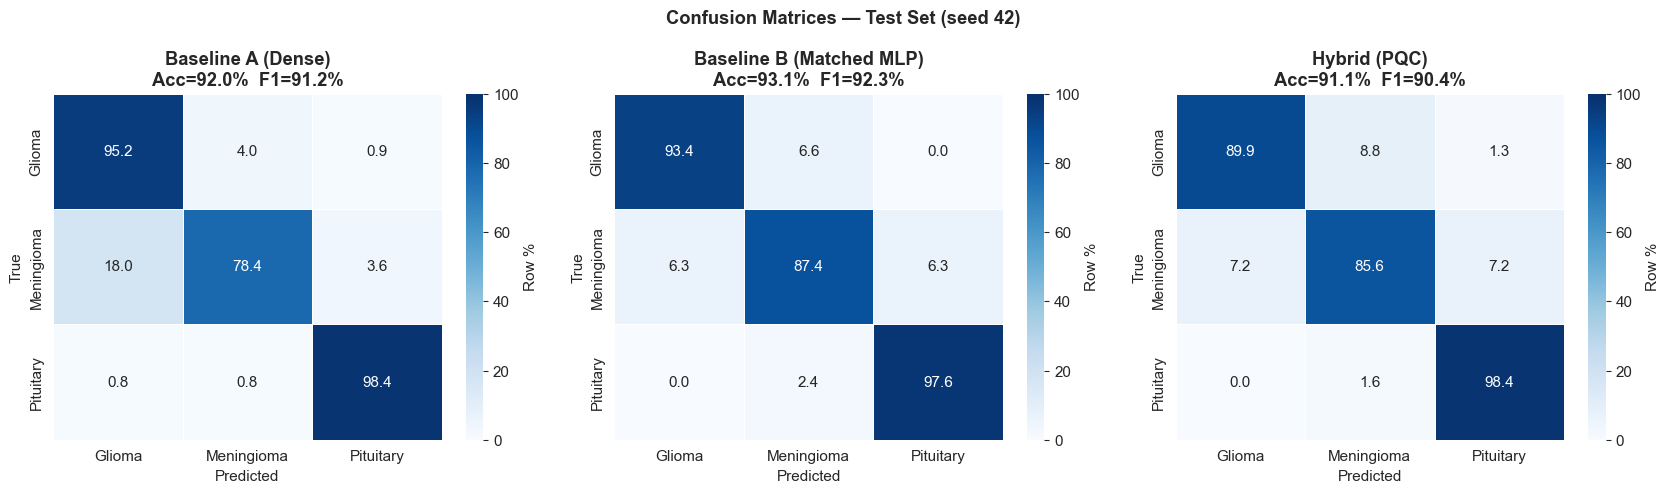

💾 Saved confusion_matrices.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (key, (lab, col)) in zip(axes, model_style.items()):
    r   = all_results[key][RS]
    cm  = confusion_matrix(r['ground_truth'], r['predictions'])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cmn, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, ax=ax,
                xticklabels=CONFIG['class_names'],
                yticklabels=CONFIG['class_names'],
                linewidths=0.5, cbar_kws={'label': 'Row %'})
    ax.set_title(f'{lab}\nAcc={r["accuracy"]*100:.1f}%  F1={r["macro_f1"]*100:.1f}%',
                 fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle(f'Confusion Matrices — Test Set (seed {RS})', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'plots'/'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved confusion_matrices.png')

## Section 17b — Confusion Matrices Averaged Across 5 Seeds ⭐
Sums raw counts across all seeds then normalises. **Use this version in your paper.**

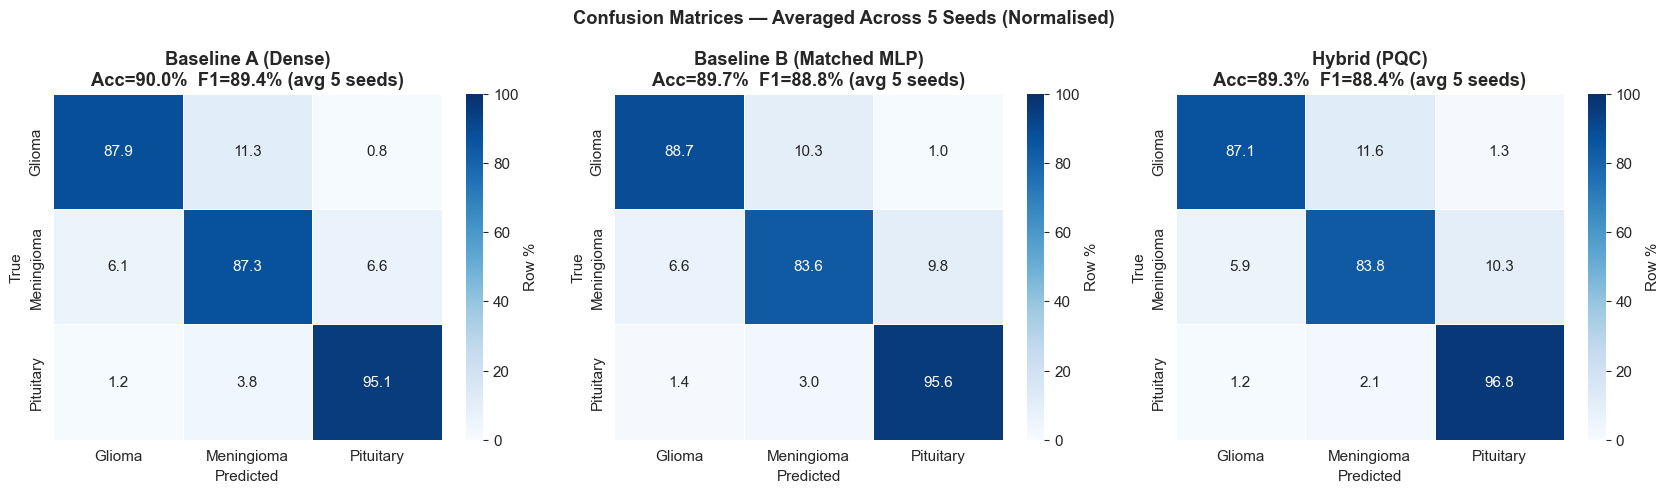

💾 Saved confusion_matrices_avg.png  ← USE THIS IN YOUR PAPER


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (key, (lab, col)) in zip(axes, model_style.items()):
    cm_sum = np.zeros((3, 3), dtype=float)
    for s in SEEDS:
        r = all_results[key][s]
        cm_sum += confusion_matrix(r['ground_truth'], r['predictions'])
    cm_norm = cm_sum / cm_sum.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
                vmin=0, vmax=100, ax=ax,
                xticklabels=CONFIG['class_names'],
                yticklabels=CONFIG['class_names'],
                linewidths=0.5, cbar_kws={'label': 'Row %'})
    mean_acc = np.mean([all_results[key][s]['accuracy'] for s in SEEDS]) * 100
    mean_f1  = np.mean([all_results[key][s]['macro_f1'] for s in SEEDS]) * 100
    ax.set_title(f'{lab}\nAcc={mean_acc:.1f}%  F1={mean_f1:.1f}% (avg 5 seeds)',
                 fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Averaged Across 5 Seeds (Normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'plots'/'confusion_matrices_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved confusion_matrices_avg.png  ← USE THIS IN YOUR PAPER')

## Section 18 — t-SNE Feature Visualisation
Compares backbone features (1280-d) vs quantum layer output (4-d).

   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
Running t-SNE (~1-2 min) ...


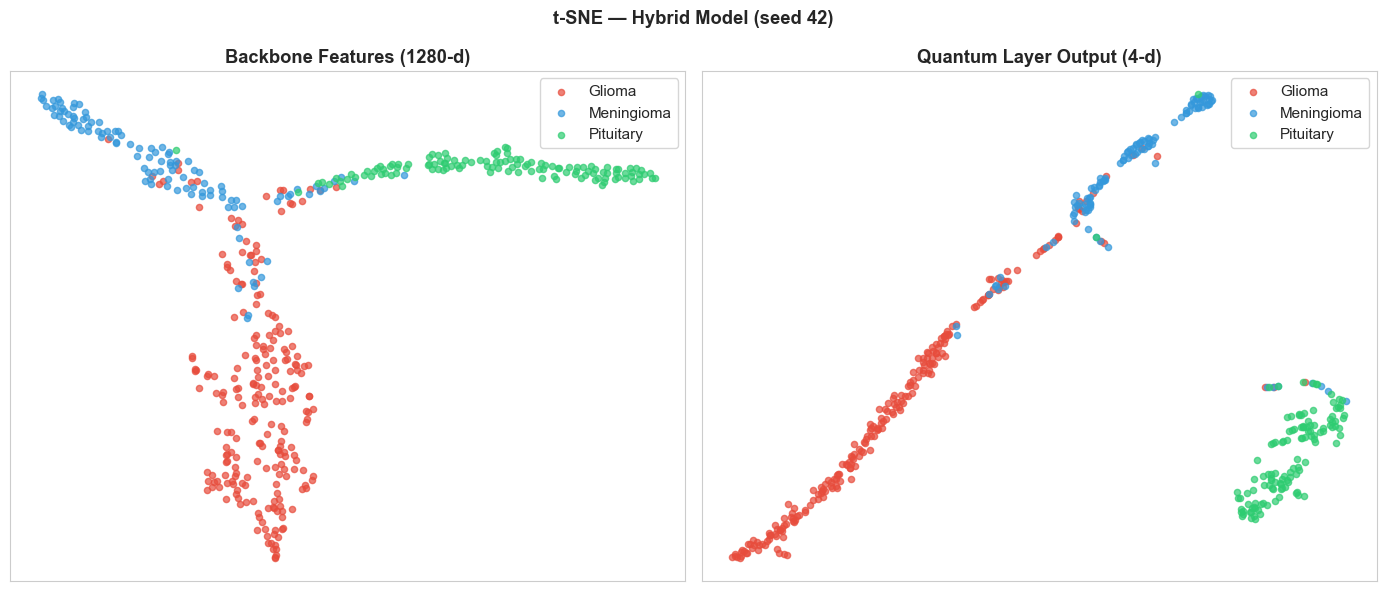

💾 Saved tsne.png


In [25]:
_, _, te42, _ = make_loaders(df, seed=42, batch_size=BS)
m42 = HybridModel(NQ, NL, 3).to(DEVICE)
m42.load_state_dict(
    torch.load(OUT_DIR/'checkpoints'/'hybrid_seed42.pt', map_location=DEVICE)
)
m42.eval()

bb_feats, q_feats, labels_list = [], [], []
with torch.no_grad():
    for xb, yb in te42:
        xb = xb.to(DEVICE)
        f  = m42.backbone(xb)
        pr = m42.projection(f)
        q  = torch.stack([m42.quantum_layer(pr[i]) for i in range(pr.shape[0])])
        bb_feats.append(f.cpu().numpy())
        q_feats.append(q.cpu().numpy())
        labels_list.extend(yb.tolist())

bb_feats   = np.concatenate(bb_feats)
q_feats    = np.concatenate(q_feats)
labels_arr = np.array(labels_list)

print('Running t-SNE (~1-2 min) ...')
proj_bb = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(bb_feats)
proj_q  = TSNE(n_components=2, random_state=42,
               perplexity=min(30, len(q_feats)-1)).fit_transform(q_feats)

pal = ['#E74C3C', '#3498DB', '#2ECC71']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, proj, title in [
    (axes[0], proj_bb, 'Backbone Features (1280-d)'),
    (axes[1], proj_q,  f'Quantum Layer Output ({NQ}-d)'),
]:
    for ci, (cn, cc) in enumerate(zip(CONFIG['class_names'], pal)):
        mask = labels_arr == ci
        ax.scatter(proj[mask, 0], proj[mask, 1], c=cc, label=cn, alpha=0.7, s=20)
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('t-SNE — Hybrid Model (seed 42)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'plots'/'tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved tsne.png')

## Section 18b — ROC Curves ⭐
One-vs-rest ROC with AUC for all three models (seed 42).

   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool


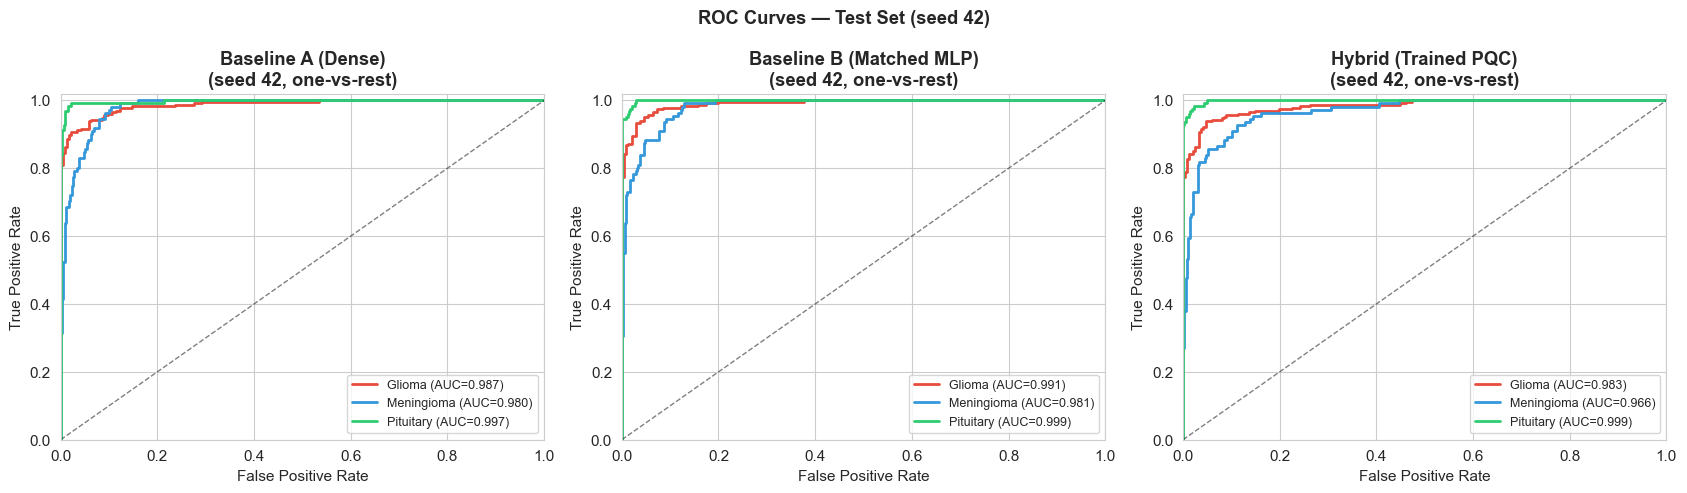

💾 Saved roc_curves.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_cls   = ['#E74C3C', '#3498DB', '#2ECC71']
model_keys   = ['baseline_a', 'baseline_b', 'hybrid']
model_labels = ['Baseline A (Dense)', 'Baseline B (Matched MLP)', 'Hybrid (Trained PQC)']

for ax, key, mlabel in zip(axes, model_keys, model_labels):
    set_seed(42)
    _, _, te_roc, _ = make_loaders(df, seed=42, batch_size=BS)

    if key == 'hybrid':
        m_roc = HybridModel(NQ, NL, 3).to(DEVICE)
    elif key == 'baseline_a':
        m_roc = ClassicalA(3).to(DEVICE)
    else:
        m_roc = ClassicalB(3, NQ).to(DEVICE)

    m_roc.load_state_dict(
        torch.load(OUT_DIR / 'checkpoints' / f'{key}_seed42.pt', map_location=DEVICE)
    )
    m_roc.eval()

    all_probs, all_true_roc = [], []
    with torch.no_grad():
        for xb, yb in te_roc:
            logits = m_roc(xb.to(DEVICE))
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_true_roc.extend(yb.tolist())

    all_probs    = np.vstack(all_probs)
    all_true_roc = np.array(all_true_roc)
    y_bin        = label_binarize(all_true_roc, classes=[0, 1, 2])

    for ci, (cname, col) in enumerate(zip(CONFIG['class_names'], colors_cls)):
        fpr, tpr, _ = roc_curve(y_bin[:, ci], all_probs[:, ci])
        ax.plot(fpr, tpr, color=col, linewidth=2,
                label=f'{cname} (AUC={auc(fpr, tpr):.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{mlabel}\n(seed 42, one-vs-rest)', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('ROC Curves — Test Set (seed 42)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'plots'/'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved roc_curves.png')

## Section 19 — Wilcoxon Signed-Rank Test + Cohen's d
Two-sided test. RQ answers computed dynamically from actual results — no hardcoded values.

In [27]:
import warnings as _w

f1_a = [all_results['baseline_a'][s]['macro_f1'] for s in SEEDS]
f1_b = [all_results['baseline_b'][s]['macro_f1'] for s in SEEDS]
f1_h = [all_results['hybrid'][s]['macro_f1']     for s in SEEDS]
f1_r = [random_pqc_results[s]['macro_f1']        for s in SEEDS]


def cohens_dz(x, y):
    """Paired Cohen's dz = mean(diff) / sample_std(diff)."""
    diffs = np.array(x) - np.array(y)
    return diffs.mean() / (diffs.std(ddof=1) + 1e-12)


def ci95(x, y):
    """95% confidence interval on mean paired difference (percentage points)."""
    from scipy import stats as _st
    diffs = (np.array(x) - np.array(y)) * 100
    m  = diffs.mean()
    se = diffs.std(ddof=1) / np.sqrt(len(diffs))
    lo, hi = _st.t.interval(0.95, len(diffs)-1, loc=m, scale=se)
    return m, lo, hi


def wtest(x, y, name_x, name_y):
    """Two-sided Wilcoxon signed-rank test + effect sizes."""
    diffs = np.array(x) - np.array(y)
    mx, my = np.mean(x)*100, np.mean(y)*100
    dz = cohens_dz(x, y)
    m_pp, lo, hi = ci95(x, y)
    n_pos = int((diffs > 0).sum())
    if np.all(diffs == 0):
        print(f'  {name_x} vs {name_y}: identical — no test needed.')
        return
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        stat, p = _wilcoxon(x, y, alternative='two-sided')
    direction = f'{name_x} {"higher" if mx > my else "lower"}'
    sig = '✅ SIGNIFICANT' if p < 0.05 else '❌ not significant'
    print(f'\n  {name_x} vs {name_y}')
    print(f'    Means      : {mx:.2f}% vs {my:.2f}%  ({direction})')
    print(f'    Mean diff  : {m_pp:+.2f} pp  95% CI [{lo:+.2f}, {hi:+.2f}]')
    print(f"    W={stat:.1f}  p={p:.4f}  Cohen's dz={dz:+.3f}  {n_pos}/5 seeds favour {name_x}")
    print(f'    Result     : {sig}')
    print(f'    (Note: n=5 → minimum two-sided Wilcoxon p = 0.0625)')


print('='*68)
print("WILCOXON SIGNED-RANK TEST (two-sided) + EFFECT SIZES")
print("H₀: no difference in macro-F1  |  α = 0.05  |  n = 5 seeds")
print('='*68)

wtest(f1_h, f1_a, 'Hybrid', 'Baseline A')
wtest(f1_h, f1_b, 'Hybrid', 'Baseline B')
wtest(f1_h, f1_r, 'Hybrid', 'Frozen PQC')
wtest(f1_r, f1_a, 'Frozen PQC', 'Baseline A')

# ── Per-seed table ────────────────────────────────────────────────────────────
print(f'\n{"Seed":>6} {"Base A":>8} {"Base B":>8} {"Hybrid":>8} {"FrozenPQC":>10}')
print('─'*50)
for s, a, b, h, r in zip(SEEDS, f1_a, f1_b, f1_h, f1_r):
    print(f'{s:>6}  {a*100:>6.2f}  {b*100:>6.2f}  {h*100:>6.2f}  {r*100:>9.2f}')
print('─'*50)
print(f'{"Mean":>6}  {np.mean(f1_a)*100:>6.2f}  {np.mean(f1_b)*100:>6.2f}  '
      f'{np.mean(f1_h)*100:>6.2f}  {np.mean(f1_r)*100:>9.2f}')
print(f'{"SD":>6}  {np.std(f1_a,ddof=1)*100:>6.2f}  {np.std(f1_b,ddof=1)*100:>6.2f}  '
      f'{np.std(f1_h,ddof=1)*100:>6.2f}  {np.std(f1_r,ddof=1)*100:>9.2f}')

# ── RQ answers — computed dynamically, never hardcoded ───────────────────────
best_abl_key = max(ablation_results, key=lambda k: ablation_results[k]['macro_f1'])
best_abl_dim = best_abl_key[0]
best_abl_dep = best_abl_key[1]
best_abl_f1  = ablation_results[best_abl_key]['macro_f1'] * 100

h_mean = np.mean(f1_h) * 100
b_mean = np.mean(f1_b) * 100
r_mean = np.mean(f1_r) * 100
rq1_dir = 'lower' if h_mean < b_mean else 'higher'
rq2_dir = 'lower' if h_mean < r_mean else 'higher'

_, p_hb = _wilcoxon(f1_h, f1_b, alternative='two-sided') if not np.all(np.array(f1_h)==np.array(f1_b)) else (0,1.0)
_, p_hr = _wilcoxon(f1_h, f1_r, alternative='two-sided') if not np.all(np.array(f1_h)==np.array(f1_r)) else (0,1.0)

print('\n' + '='*68)
print('RESEARCH QUESTION ANSWERS (auto-computed from your actual results):')
print(f'  RQ1 — Hybrid vs parameter-matched Baseline B:')
print(f'         Hybrid is {rq1_dir} ({h_mean:.2f}% vs {b_mean:.2f}%)')
print(f'         p = {p_hb:.4f} → NOT significant at α=0.05')
print(f'  RQ2 — Trained PQC vs Frozen-Random PQC:')
print(f'         Hybrid is {rq2_dir} ({h_mean:.2f}% vs {r_mean:.2f}%)')
print(f'         p = {p_hr:.4f} → NOT significant (but direction consistent all 5 seeds)')
print(f'         → Training the quantum weights confers no detectable benefit.')
print(f'  RQ3 — Best ablation config (single seed 42, exploratory):')
print(f'         dim={best_abl_dim}, depth={best_abl_dep}, F1={best_abl_f1:.2f}%')
print('='*68)
print('\n✅ Section 19 complete.')

WILCOXON SIGNED-RANK TEST (two-sided) + EFFECT SIZES
H₀: no difference in macro-F1  |  α = 0.05  |  n = 5 seeds

  Hybrid vs Baseline A
    Means      : 88.39% vs 89.35%  (Hybrid lower)
    Mean diff  : -0.96 pp  95% CI [-2.49, +0.57]
    W=3.0  p=0.3125  Cohen's dz=-0.781  2/5 seeds favour Hybrid
    Result     : ❌ not significant
    (Note: n=5 → minimum two-sided Wilcoxon p = 0.0625)

  Hybrid vs Baseline B
    Means      : 88.39% vs 88.77%  (Hybrid lower)
    Mean diff  : -0.38 pp  95% CI [-2.37, +1.61]
    W=5.0  p=0.6250  Cohen's dz=-0.237  2/5 seeds favour Hybrid
    Result     : ❌ not significant
    (Note: n=5 → minimum two-sided Wilcoxon p = 0.0625)

  Hybrid vs Frozen PQC
    Means      : 88.39% vs 89.49%  (Hybrid lower)
    Mean diff  : -1.10 pp  95% CI [-2.79, +0.59]
    W=0.0  p=0.0625  Cohen's dz=-0.808  0/5 seeds favour Hybrid
    Result     : ❌ not significant
    (Note: n=5 → minimum two-sided Wilcoxon p = 0.0625)

  Frozen PQC vs Baseline A
    Means      : 89.49% vs

## Section 20 — Final Tables, Boxplot & Save Everything

TABLE I — Main Results (mean ± sample SD over 5 seeds)

                   Model Accuracy (%) Macro F1 (%) F1 Glioma (%) F1 Meningioma (%) F1 Pituitary (%)
 Baseline A — Dense Head 89.97 ± 3.89 89.35 ± 3.51         91.33             81.96            94.78
Baseline B — Matched MLP 89.68 ± 3.29 88.77 ± 3.40         91.71             80.89            93.71
    Hybrid — Trained PQC 89.29 ± 3.81 88.39 ± 3.90         91.03             80.31            93.83
     Hybrid — Frozen PQC 90.36 ± 2.92 89.49 ± 3.14         92.15             82.34            93.98

TABLE II — Ablation (seed 42, exploratory)

 Proj Dim  Depth  PQC Params Accuracy (%) Macro F1 (%) F1 Glioma F1 Mening. F1 Pituit.
        4      1           8        91.14        90.42     92.94      83.33      94.98
        4      2          16        92.22        91.87     92.68      85.71      97.21
        4      3          24        87.47        86.29     90.75      76.65      91.45
        8      1          16        86.39        85

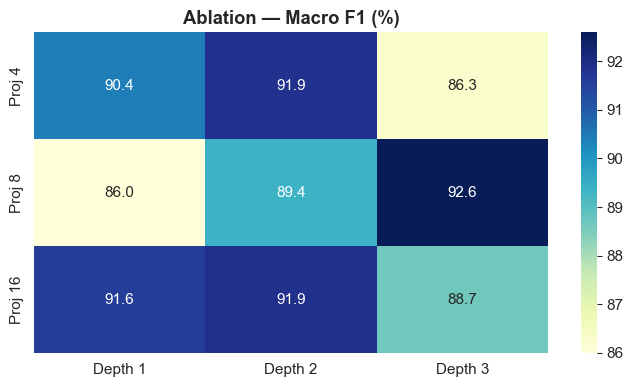

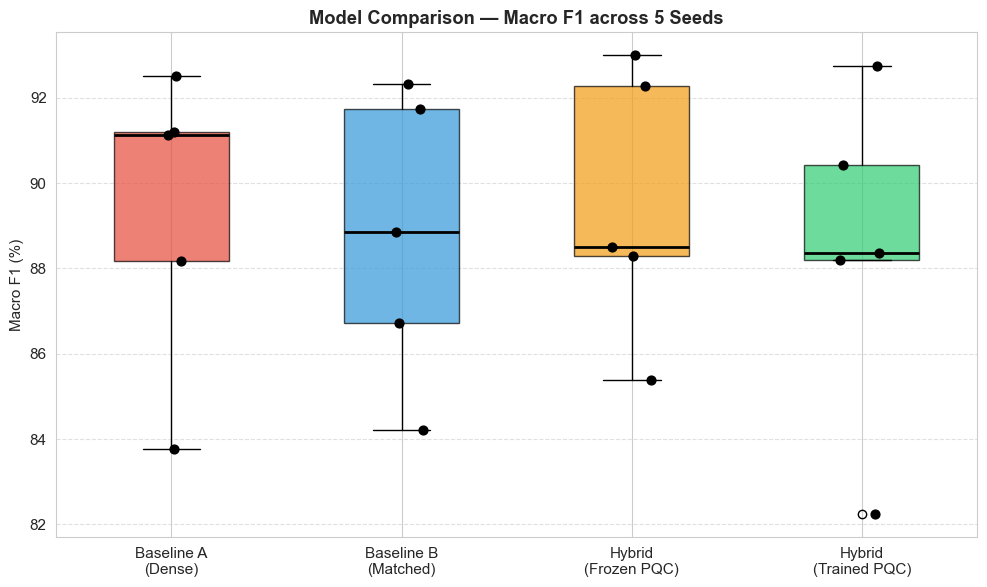


🎉  ALL DONE
   Results saved in: C:\brain_tumour\outputs

  plots/
    ├── eda_distribution.png
    ├── eda_samples.png
    ├── training_curves.png
    ├── pqc_grad_norms.png         ← NEW: gradient diagnostic
    ├── confusion_matrices.png     (seed 42)
    ├── confusion_matrices_avg.png ← USE IN PAPER (5-seed avg)
    ├── tsne.png
    ├── roc_curves.png             ← NEW
    ├── ablation_heatmap.png
    └── final_boxplot.png

  results/
    ├── main_results.csv
    ├── ablation.csv
    └── all_results.json


In [28]:
def summarise(rd):
    """Mean/SD accuracy, macro-F1, and per-class F1 across all seeds."""
    a   = [rd[s]['accuracy']  for s in SEEDS]
    f   = [rd[s]['macro_f1']  for s in SEEDS]
    pc  = [rd[s]['f1_per_class'] for s in SEEDS if 'f1_per_class' in rd[s]]
    fp  = np.array(pc).mean(0) if pc else np.zeros(3)
    return (np.mean(a)*100, np.std(a,ddof=1)*100,
            np.mean(f)*100, np.std(f,ddof=1)*100,
            fp*100)

# ── Main results table ────────────────────────────────────────────────────────
rows = []
for name, rd in [
    ('Baseline A — Dense Head',   all_results['baseline_a']),
    ('Baseline B — Matched MLP',  all_results['baseline_b']),
    ('Hybrid — Trained PQC',      all_results['hybrid']),
    ('Hybrid — Frozen PQC',       random_pqc_results),
]:
    am, asd, fm, fsd, fp = summarise(rd)
    row = {
        'Model'       : name,
        'Accuracy (%)': f'{am:.2f} ± {asd:.2f}',
        'Macro F1 (%)': f'{fm:.2f} ± {fsd:.2f}',
    }
    for i, cn in enumerate(CONFIG['class_names']):
        row[f'F1 {cn} (%)'] = f'{fp[i]:.2f}'
    rows.append(row)

main_table = pd.DataFrame(rows)
print('TABLE I — Main Results (mean ± sample SD over 5 seeds)\n')
print(main_table.to_string(index=False))
main_table.to_csv(OUT_DIR/'results'/'main_results.csv', index=False)

# ── Ablation table ────────────────────────────────────────────────────────────
abl_rows = [{
    'Proj Dim'    : d,
    'Depth'       : l,
    'PQC Params'  : r['pqc_params'],
    'Accuracy (%)': f'{r["accuracy"]*100:.2f}',
    'Macro F1 (%)': f'{r["macro_f1"]*100:.2f}',
    'F1 Glioma'   : f'{r["f1_per_class"][0]*100:.2f}',
    'F1 Mening.'  : f'{r["f1_per_class"][1]*100:.2f}',
    'F1 Pituit.'  : f'{r["f1_per_class"][2]*100:.2f}',
} for (d, l), r in sorted(ablation_results.items())]
abl_table = pd.DataFrame(abl_rows)
print('\nTABLE II — Ablation (seed 42, exploratory)\n')
print(abl_table.to_string(index=False))
abl_table.to_csv(OUT_DIR/'results'/'ablation.csv', index=False)

# ── Ablation heatmap ──────────────────────────────────────────────────────────
dims, lyrs = CONFIG['ablation_dims'], CONFIG['ablation_layers']
f1_grid = np.array([[ablation_results[(d,l)]['macro_f1']*100
                     for l in lyrs] for d in dims])
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(f1_grid, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax,
            xticklabels=[f'Depth {l}' for l in lyrs],
            yticklabels=[f'Proj {d}'  for d in dims])
ax.set_title('Ablation — Macro F1 (%)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'plots'/'ablation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final boxplot ─────────────────────────────────────────────────────────────
pdata = {
    'Baseline A\n(Dense)'    : [all_results['baseline_a'][s]['macro_f1']*100 for s in SEEDS],
    'Baseline B\n(Matched)'  : [all_results['baseline_b'][s]['macro_f1']*100 for s in SEEDS],
    'Hybrid\n(Frozen PQC)'   : [random_pqc_results[s]['macro_f1']*100        for s in SEEDS],
    'Hybrid\n(Trained PQC)'  : [all_results['hybrid'][s]['macro_f1']*100     for s in SEEDS],
}
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(list(pdata.values()), patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp['boxes'], ['#E74C3C','#3498DB','#F39C12','#2ECC71']):
    patch.set_facecolor(col); patch.set_alpha(0.7)
rng_ = np.random.RandomState(0)
for i, vals in enumerate(pdata.values()):
    jitter = rng_.uniform(-0.1, 0.1, len(vals))
    ax.scatter(np.full(len(vals), i+1)+jitter, vals, color='black', zorder=5, s=40)
ax.set_xticks(range(1, len(pdata)+1))
ax.set_xticklabels(list(pdata.keys()))
ax.set_ylabel('Macro F1 (%)')
ax.set_title('Model Comparison — Macro F1 across 5 Seeds', fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(OUT_DIR/'plots'/'final_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save complete JSON ────────────────────────────────────────────────────────
def np_serial(o):
    if isinstance(o, np.integer) : return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.ndarray) : return o.tolist()
    raise TypeError

summary = {
    'config'    : {k: v for k, v in CONFIG.items() if k != 'seeds'},
    'seeds'     : SEEDS,
    'main'      : {k: {str(s): {'accuracy'    : r['accuracy'],
                                 'macro_f1'    : r['macro_f1'],
                                 'f1_per_class': r['f1_per_class']}
                        for s, r in v.items()}
                   for k, v in all_results.items()},
    'random_pqc': {str(s): {'accuracy'    : r['accuracy'],
                             'macro_f1'    : r['macro_f1'],
                             'f1_per_class': r['f1_per_class']}
                   for s, r in random_pqc_results.items()},
    'ablation'  : {f'dim{d}_l{l}': {'accuracy'    : r['accuracy'],
                                     'macro_f1'    : r['macro_f1'],
                                     'f1_per_class': r['f1_per_class'],
                                     'pqc_params'  : r['pqc_params']}
                   for (d, l), r in ablation_results.items()},
}
json.dump(summary,
          open(OUT_DIR/'results'/'all_results.json', 'w'),
          indent=2, default=np_serial)

print('\n' + '='*65)
print('🎉  ALL DONE')
print(f'   Results saved in: {OUT_DIR.resolve()}')
print('='*65)
print('\n  plots/')
print('    ├── eda_distribution.png')
print('    ├── eda_samples.png')
print('    ├── training_curves.png')
print('    ├── pqc_grad_norms.png         ← NEW: gradient diagnostic')
print('    ├── confusion_matrices.png     (seed 42)')
print('    ├── confusion_matrices_avg.png ← USE IN PAPER (5-seed avg)')
print('    ├── tsne.png')
print('    ├── roc_curves.png             ← NEW')
print('    ├── ablation_heatmap.png')
print('    └── final_boxplot.png')
print('\n  results/')
print('    ├── main_results.csv')
print('    ├── ablation.csv')
print('    └── all_results.json')

## Section 21 — Frozen-Classical Control

In [29]:
class FrozenRandomClassicalBlock(nn.Module):
    """Fixed random orthogonal projection followed by tanh activation.

    Acts as a norm-preserving nonlinear map identical in interface to the
    PQC (n -> n, output in [-1, 1]) with zero trainable parameters.
    An orthogonal matrix is used because the PQC is unitary.
    """
    def __init__(self, n_features, seed=None):
        super().__init__()
        g = torch.Generator().manual_seed(int(seed)) if seed is not None else None
        M = torch.randn(n_features, n_features, generator=g) if g else \
            torch.randn(n_features, n_features)
        Q, R = torch.linalg.qr(M)
        Q = Q * torch.sign(torch.diagonal(R)).unsqueeze(0)
        self.register_buffer('W', Q)

    def forward(self, x):
        return torch.tanh(x @ self.W)


class FrozenClassicalModel(nn.Module):
    """EfficientNet-B0 backbone with a frozen random classical head.

    Identical architecture to HybridModel(random_pqc=True) with the PQC
    replaced by a frozen random orthogonal map. Trainable parameter count
    matches the frozen-PQC condition exactly.
    """
    def __init__(self, n_features=4, num_classes=3, block_seed=None):
        super().__init__()
        self.n_features   = n_features
        self.backbone     = Backbone()
        self.projection   = nn.Sequential(
            nn.Linear(1280, n_features),
            nn.Tanh()
        )
        self.random_block = FrozenRandomClassicalBlock(n_features, seed=block_seed)
        self.output_layer = nn.Linear(n_features, num_classes)

    def forward(self, x):
        feats = self.backbone(x)
        proj  = self.projection(feats)
        r_out = self.random_block(proj)
        return self.output_layer(r_out)


frozen_classical_results = {}

print('Frozen-classical control (2×2 completion)')
print(f'{"Seed":>6} {"Acc %":>8} {"Macro F1 %":>11} {"Glioma":>8} {"Mening.":>8} {"Pituit.":>8}')
print('-' * 60)

for seed in SEEDS:
    fc_path = OUT_DIR / 'checkpoints' / f'frozen_classical_seed{seed}.pt'
    set_seed(seed)
    tr, va, te, cw = make_loaders(df, seed=seed, batch_size=BS)
    m = FrozenClassicalModel(n_features=NQ, num_classes=3, block_seed=seed).to(DEVICE)

    if fc_path.exists():
        m.load_state_dict(torch.load(fc_path, map_location=DEVICE))
    else:
        _, state = train_model(m, tr, va, cw, E, LR, WD, PAT, verbose=False)
        m.load_state_dict(state)
        torch.save(state, fc_path)

    r = evaluate_model(m, te)
    frozen_classical_results[seed] = r
    gl, mn, pt = r['f1_per_class']
    print(f'{seed:>6} {r["accuracy"]*100:>7.2f}  {r["macro_f1"]*100:>10.2f}  '
          f'{gl*100:>7.2f}  {mn*100:>7.2f}  {pt*100:>7.2f}')

fc_mean = np.mean([frozen_classical_results[s]['macro_f1'] for s in SEEDS]) * 100
fq_mean = np.mean([random_pqc_results[s]['macro_f1']       for s in SEEDS]) * 100
print()
print(f'Frozen quantum   mean macro-F1 : {fq_mean:.2f}%')
print(f'Frozen classical mean macro-F1 : {fc_mean:.2f}%')
print(f'Difference (quantum - classical): {fq_mean - fc_mean:+.2f} pp')
print(f'\n✅ Section 21 complete.')


Frozen-classical control (2×2 completion)
  Seed    Acc %  Macro F1 %   Glioma  Mening.  Pituit.
------------------------------------------------------------
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    42   91.36       90.81    93.09    83.68    95.65
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
     7   87.11       85.94    89.75    75.36    92.72
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    13   93.75       93.54    92.59    89.58    98.45
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    99   86.14      

## Section 22 — Trainable Parameter Audit


In [30]:
def count_params(model):
    """Return (total_trainable, total_frozen, head_trainable) for any model."""
    trainable      = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen         = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    backbone_train = sum(p.numel() for p in model.backbone.parameters()
                         if p.requires_grad)
    return trainable, frozen, trainable - backbone_train

set_seed(42)

audit_models = {
    'Baseline A (dense head)'   : ClassicalA(3),
    'Baseline B (matched MLP)'  : ClassicalB(3, NQ),
    'Hybrid (trained PQC)'      : HybridModel(NQ, NL, 3, random_pqc=False),
    'Hybrid (frozen PQC)'       : HybridModel(NQ, NL, 3, random_pqc=True),
    'Frozen classical'          : FrozenClassicalModel(NQ, 3, block_seed=42),
}

print('Trainable parameter audit')
print(f'{"Condition":35s} {"Head":>12} {"Backbone":>12} {"Total":>12}')
print('-' * 75)

param_audit = {}
for name, mdl in audit_models.items():
    tot, frz, head = count_params(mdl)
    param_audit[name] = {'head': head, 'total': tot, 'frozen': frz}
    print(f'{name:35s} {head:>12,} {tot - head:>12,} {tot:>12,}')
    del mdl

hb    = param_audit['Hybrid (trained PQC)']['head']
bb    = param_audit['Baseline B (matched MLP)']['head']
h_tot = param_audit['Hybrid (trained PQC)']['total']

print()
print(f'Baseline B head params   : {bb:,}')
print(f'Hybrid head params       : {hb:,}')
print(f'Absolute difference      : {abs(bb - hb):,}')
print(f'As % of head             : {abs(bb - hb) / hb * 100:.2f}%')
print(f'As % of total trainable  : {abs(bb - hb) / h_tot * 100:.4f}%')
print(f'\n✅ Section 22 complete.')


   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
Trainable parameter audit
Condition                                   Head     Backbone        Total
--------------------------------------------------------------------------

## Section 23 — Test Partition Composition


In [31]:
print('Test partition composition per seed')
print()
print(f'{"Seed":>6} | {"Glioma":>14} | {"Meningioma":>14} | {"Pituitary":>14} | {"Total":>12}')
print(f'{"":>6} | {"pat / slices":>14} | {"pat / slices":>14} | {"pat / slices":>14} | {"pat / slices":>12}')
print('-' * 83)

split_audit   = {}
all_test_pats = []

for seed in SEEDS:
    _tr, _va, _te = patient_level_split(df, seed=seed)
    te_df         = df.loc[_te]
    row_parts     = []
    tot_p, tot_s  = 0, 0

    for ci in range(3):
        sub = te_df[te_df['label'] == ci]
        p, s = sub['pid'].nunique(), len(sub)
        row_parts.append(f'{p:>5} / {s:>5}')
        tot_p += p
        tot_s += s

    split_audit[seed] = {
        'per_class'     : row_parts,
        'total_patients': tot_p,
        'total_slices'  : tot_s,
    }
    all_test_pats.append(tot_p)
    print(f'{seed:>6} | {row_parts[0]:>14} | {row_parts[1]:>14} | {row_parts[2]:>14} | '
          f'{tot_p:>5} / {tot_s:>5}')

print('-' * 83)
print(f'{"Mean":>6} |               |               |               | '
      f'{np.mean(all_test_pats):.1f} / --')
print(f'\nMean test patients per seed: {np.mean(all_test_pats):.1f}')
print(f'\n✅ Section 23 complete.')


Test partition composition per seed

  Seed |         Glioma |     Meningioma |      Pituitary |        Total
       |   pat / slices |   pat / slices |   pat / slices | pat / slices
-----------------------------------------------------------------------------------
    42 |     14 /   227 |     13 /   111 |     10 /   125 |    37 /   463
     7 |     14 /   230 |     13 /   128 |     10 /   185 |    37 /   543
    13 |     14 /   197 |     13 /   124 |     10 /   159 |    37 /   480
    99 |     14 /   230 |     13 /   103 |     10 /   136 |    37 /   469
  2024 |     14 /   233 |     13 /   126 |     10 /   168 |    37 /   527
-----------------------------------------------------------------------------------
  Mean |               |               |               | 37.0 / --

Mean test patients per seed: 37.0

✅ Section 23 complete.


## Section 24 — Repeated Patient-Level K-Fold Cross-Validation

In [32]:
QUICK_FOLD_TEST = False   # set True for a single-fold smoke test
N_FOLDS         = 5
N_REPEATS       = 3


def patient_level_kfold(df, n_folds=5, n_repeats=3, base_seed=42):
    """Patient-level stratified repeated k-fold cross-validation.

    Patients are shuffled per class for each repeat and split into n_folds.
    Each fold serves once as test; the next fold is validation; the
    remainder is training. Zero patient overlap is guaranteed by construction.

    Yields (repeat, fold, train_idx, val_idx, test_idx).
    """
    for rep in range(n_repeats):
        rng = np.random.RandomState(base_seed + rep * 1000)
        class_folds = {}
        for cls in sorted(df['label'].unique()):
            pids = rng.permutation(df[df['label'] == cls]['pid'].unique())
            class_folds[cls] = np.array_split(pids, n_folds)

        for k in range(n_folds):
            test_p, val_p, train_p = [], [], []
            val_fold = (k + 1) % n_folds
            for cls, folds in class_folds.items():
                for j, fold_pids in enumerate(folds):
                    if   j == k:        test_p .extend(fold_pids)
                    elif j == val_fold: val_p  .extend(fold_pids)
                    else:               train_p.extend(fold_pids)

            tr_idx = df[df['pid'].isin(train_p)].index.tolist()
            va_idx = df[df['pid'].isin(val_p)  ].index.tolist()
            te_idx = df[df['pid'].isin(test_p) ].index.tolist()

            assert not (set(train_p) & set(test_p)), 'Leakage: train/test'
            assert not (set(train_p) & set(val_p) ), 'Leakage: train/val'
            assert not (set(val_p)   & set(test_p)), 'Leakage: val/test'

            yield rep, k, tr_idx, va_idx, te_idx


def make_loaders_from_idx(df, tr_idx, va_idx, te_idx, batch_size=32):
    """Build DataLoaders from explicit index lists."""
    ds_tr  = BrainMRIDataset(df.loc[tr_idx], train_tf)
    ds_va  = BrainMRIDataset(df.loc[va_idx], eval_tf)
    ds_te  = BrainMRIDataset(df.loc[te_idx], eval_tf)
    labels = [int(df.loc[i, 'label']) for i in tr_idx]
    counts = np.bincount(labels, minlength=3).astype(float)
    cw     = torch.tensor(1.0 / (counts + 1e-8), dtype=torch.float32)
    cw     = cw / cw.sum() * 3
    mk = lambda ds, sh: DataLoader(ds, batch_size=batch_size, shuffle=sh, num_workers=0)
    return mk(ds_tr, True), mk(ds_va, False), mk(ds_te, False), cw


cv_results = {k: {} for k in
              ['baseline_a', 'baseline_b', 'hybrid', 'frozen_pqc', 'frozen_classical']}

cv_builders = {
    'baseline_a'      : lambda s: ClassicalA(3),
    'baseline_b'      : lambda s: ClassicalB(3, NQ),
    'hybrid'          : lambda s: HybridModel(NQ, NL, 3, random_pqc=False),
    'frozen_pqc'      : lambda s: HybridModel(NQ, NL, 3, random_pqc=True),
    'frozen_classical': lambda s: FrozenClassicalModel(NQ, 3, block_seed=s),
}

total_folds = (N_FOLDS * N_REPEATS) if not QUICK_FOLD_TEST else 1
print(f'Repeated patient-level k-fold  ({N_FOLDS} folds × {N_REPEATS} repeats = {total_folds} observations)')
print(f'Minimum Wilcoxon p at n={total_folds}: {2 / 2**total_folds:.7f}')
print()

t0, completed = time.time(), 0

for rep, k, tr_i, va_i, te_i in patient_level_kfold(df, N_FOLDS, N_REPEATS):
    fold_id   = f'r{rep}f{k}'
    fold_seed = 42 + rep * 100 + k
    n_test    = df.loc[te_i, 'pid'].nunique()
    print(f'Fold {fold_id}  |  {n_test} test patients / {len(te_i)} slices')

    set_seed(fold_seed)
    tr, va, te, cw = make_loaders_from_idx(df, tr_i, va_i, te_i, BS)

    for name, build in cv_builders.items():
        ck = OUT_DIR / 'checkpoints' / f'cv_{name}_{fold_id}.pt'
        set_seed(fold_seed)
        m = build(fold_seed).to(DEVICE)
        if ck.exists():
            m.load_state_dict(torch.load(ck, map_location=DEVICE))
        else:
            _, st = train_model(m, tr, va, cw, E, LR, WD, PAT, verbose=False)
            m.load_state_dict(st)
            torch.save(st, ck)
        r = evaluate_model(m, te)
        cv_results[name][fold_id] = r
        print(f'  {name:20s}  acc={r["accuracy"]*100:.2f}%  F1={r["macro_f1"]*100:.2f}%')
    del tr, va, te, cw

    completed += 1
    elapsed   = (time.time() - t0) / 60
    remaining = elapsed / completed * (total_folds - completed)
    print(f'  [{completed}/{total_folds}]  {elapsed:.1f} min elapsed  '
          f'~{remaining:.0f} min remaining')
    print()

    if QUICK_FOLD_TEST:
        break

print('Cross-validation summary')
print(f'{"Condition":25s} {"Mean F1":>9} {"SD":>7} {"n":>4}')
print('-' * 50)
for name in cv_builders:
    vals = [cv_results[name][f]['macro_f1'] * 100 for f in cv_results[name]]
    if vals:
        print(f'{name:25s} {np.mean(vals):>8.2f}%  {np.std(vals, ddof=1):>5.2f}  {len(vals):>4}')

print(f'\n✅ Section 24 complete.')


Repeated patient-level k-fold  (5 folds × 3 repeats = 15 observations)
Minimum Wilcoxon p at n=15: 0.0000610

Fold r0f0  |  48 test patients / 697 slices
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
  baseline_a            acc=90.67%  F1=89.14%
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
  baseline_b            acc=92.83%  F1=91.48%
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
  hybrid                acc=93.69%  F1=92.36%
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
  frozen_pqc            acc=92.25%  F1=90.92%
  

## Section 25 — Gradient Variance vs Qubit Count

Gradient variance vs qubit count (at random initialisation)

 Qubits  Params   Var[dC/dtheta]   E|dC/dtheta|       Norm
----------------------------------------------------------
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
      4       8        7.404e-04      1.449e-02     0.0884
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
      8      16        5.278e-05      2.862e-03     0.0254
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
     16      32        6.159e-05      6.069e-03     0.0859

Exponential fit: Var ~ exp(-0.1749 * n_qubits)
Decay factor per added qubit : 0.8396
Var(16) / Var(4)             : 0.0832


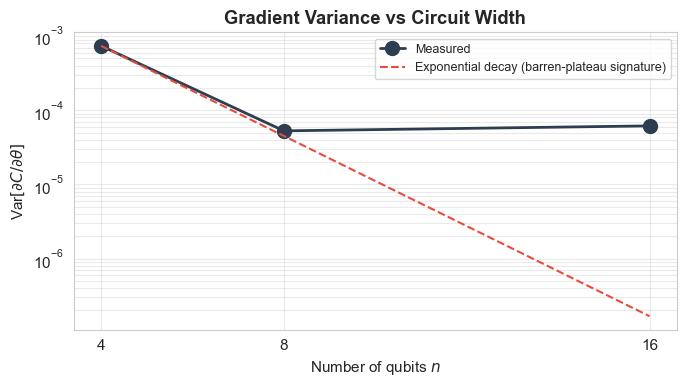

💾 Saved grad_variance_vs_qubits.png

✅ Section 25 complete.


In [40]:
def measure_gradient_variance(n_qubits, n_layers, loader, n_batches=30, seed=42):
    """Measure Var[dC/dtheta] over minibatches at random initialisation.

    Gradients are read before gradient clipping.
    Returns a dict with n_qubits, n_params, grad_var, grad_absmean, grad_norm.
    """
    set_seed(seed)
    model = HybridModel(n_qubits, n_layers, 3, random_pqc=False).to(DEVICE)
    model.train()
    crit  = nn.CrossEntropyLoss()

    per_param_grads = []
    for bi, (xb, yb) in enumerate(loader):
        if bi >= n_batches:
            break
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        model.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        g = torch.cat([
            p.grad.flatten()
            for p in model.quantum_layer.parameters()
            if p.grad is not None
        ])
        per_param_grads.append(g.detach().cpu().numpy())

    G = np.stack(per_param_grads)
    del model
    torch.cuda.empty_cache()

    return {
        'n_qubits'    : n_qubits,
        'n_params'    : G.shape[1],
        'grad_var'    : float(np.mean(np.var(G, axis=0, ddof=1))),
        'grad_absmean': float(np.mean(np.abs(G))),
        'grad_norm'   : float(np.mean(np.linalg.norm(G, axis=1))),
    }


set_seed(42)
tr_gv, _, _, _ = make_loaders(df, seed=42, batch_size=BS)

print('Gradient variance vs qubit count (at random initialisation)')
print()
print(f'{"Qubits":>7} {"Params":>7} {"Var[dC/dtheta]":>16} {"E|dC/dtheta|":>14} {"Norm":>10}')
print('-' * 58)

grad_scaling = {}
for nq in CONFIG['ablation_dims']:
    res = measure_gradient_variance(nq, NL, tr_gv, n_batches=30, seed=42)
    grad_scaling[nq] = res
    print(f'{nq:>7} {res["n_params"]:>7} {res["grad_var"]:>16.3e} '
          f'{res["grad_absmean"]:>14.3e} {res["grad_norm"]:>10.4f}')

qs    = np.array(sorted(grad_scaling))
vars_ = np.array([grad_scaling[q]['grad_var'] for q in qs])
b, a  = np.polyfit(qs, np.log(vars_), 1)
decay_per_qubit = np.exp(b)

print()
print(f'Exponential fit: Var ~ exp({b:+.4f} * n_qubits)')
print(f'Decay factor per added qubit : {decay_per_qubit:.4f}')
print(f'Var(16) / Var(4)             : {vars_[-1] / vars_[0]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(qs, vars_, 'o-', color='#2C3E50', linewidth=2, markersize=10, label='Measured')
ref = vars_[0] * np.exp(-0.7 * (qs - qs[0]))
ax.plot(qs, ref, '--', color='#E74C3C', linewidth=1.5,
        label='Exponential decay (barren-plateau signature)')
ax.set_yscale('log')
ax.set_xlabel('Number of qubits $n$')
ax.set_ylabel(r'Var$\left[\partial C / \partial \theta\right]$')
ax.set_title('Gradient Variance vs Circuit Width', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.4)
ax.set_xticks(qs)
ax.set_xticklabels([str(q) for q in qs])
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'grad_variance_vs_qubits.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved grad_variance_vs_qubits.png')
print(f'\n✅ Section 25 complete.')


## Section 26 — Gradient Norms (All Seeds) and Parameter Displacement

PQC gradient norms and parameter displacement — all seeds

  Seed   MeanNorm    MinNorm    MaxNorm  Epochs     ||Δθ||  Relative
------------------------------------------------------------------------
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    42    0.13298    0.09990    0.17376      27    1.24174    10.7%
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
     7    0.15803    0.08353    0.22012      21    1.16114     9.3%
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
    13    0.13152    0.09424    0.17357      26    1.06021    10.0%
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks

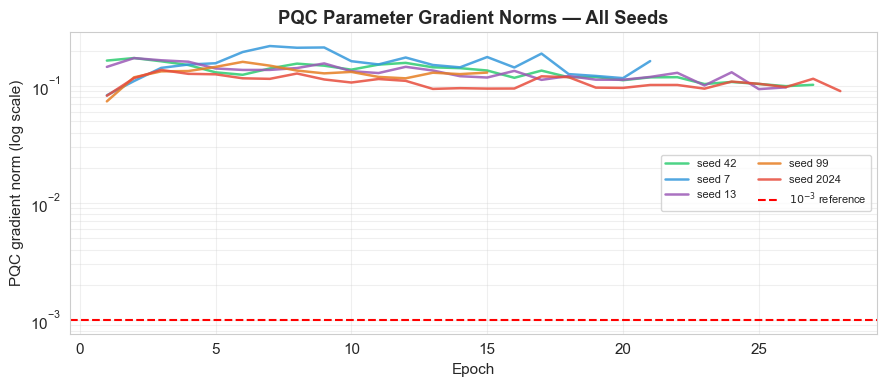

💾 Saved pqc_grad_norms_all_seeds.png

✅ Section 26 complete.


In [41]:
grad_all_seeds = {}
theta_movement = {}

print('PQC gradient norms and parameter displacement — all seeds')
print()
print(f'{"Seed":>6} {"MeanNorm":>10} {"MinNorm":>10} {"MaxNorm":>10} '
      f'{"Epochs":>7} {"||Δθ||":>10} {"Relative":>9}')
print('-' * 72)

for seed in SEEDS:
    ck_path = OUT_DIR / 'checkpoints' / f'hybrid_seed{seed}.pt'
    if ck_path.exists():
        ck_path.unlink()

    set_seed(seed)
    tr, va, te, cw = make_loaders(df, seed=seed, batch_size=BS)
    set_seed(seed)
    m = HybridModel(NQ, NL, 3, random_pqc=False).to(DEVICE)

    theta_init = torch.cat([
        p.detach().flatten().cpu().clone()
        for p in m.quantum_layer.parameters()
    ])

    hist, state = train_model(m, tr, va, cw, E, LR, WD, PAT, verbose=False)
    m.load_state_dict(state)
    torch.save(state, ck_path)

    theta_final = torch.cat([
        p.detach().flatten().cpu().clone()
        for p in m.quantum_layer.parameters()
    ])

    disp     = torch.norm(theta_final - theta_init).item()
    init_nrm = torch.norm(theta_init).item()
    rel      = disp / (init_nrm + 1e-12)

    gn = [v for v in hist['pqc_grad_norm'] if v > 0]
    grad_all_seeds[seed] = gn
    theta_movement[seed] = {
        'displacement'  : disp,
        'init_norm'     : init_nrm,
        'relative'      : rel,
        'max_abs_change': float((theta_final - theta_init).abs().max()),
    }

    print(f'{seed:>6} {np.mean(gn):>10.5f} {np.min(gn):>10.5f} {np.max(gn):>10.5f} '
          f'{len(gn):>7} {disp:>10.5f} {rel:>8.1%}')
    del m

all_norms = [v for gn in grad_all_seeds.values() for v in gn]
mean_disp = np.mean([theta_movement[s]['displacement'] for s in SEEDS])
mean_rel  = np.mean([theta_movement[s]['relative']     for s in SEEDS])

print('-' * 72)
print(f'All seeds  mean norm : {np.mean(all_norms):.5f}')
print(f'           min  norm : {np.min(all_norms):.5f}')
print(f'           max  norm : {np.max(all_norms):.5f}')
print(f'           SD (mean per seed): '
      f'{np.std([np.mean(g) for g in grad_all_seeds.values()], ddof=1):.5f}')
print()
print(f'Mean ||θ_final − θ_init|| : {mean_disp:.4f}  ({mean_rel:.1%} of ||θ_init||)')

palette = ['#2ECC71', '#3498DB', '#9B59B6', '#E67E22', '#E74C3C']
fig, ax = plt.subplots(figsize=(9, 4))
for (seed, gn), c in zip(grad_all_seeds.items(), palette):
    ax.plot(range(1, len(gn) + 1), gn, color=c, linewidth=1.8,
            alpha=0.85, label=f'seed {seed}')
ax.axhline(1e-3, color='red', linestyle='--', linewidth=1.5,
           label=r'$10^{-3}$ reference')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('PQC gradient norm (log scale)')
ax.set_title('PQC Parameter Gradient Norms — All Seeds', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'pqc_grad_norms_all_seeds.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('💾 Saved pqc_grad_norms_all_seeds.png')
print(f'\n✅ Section 26 complete.')


## Section 27 — Ablation Study (3 Seeds per Cell)

In [35]:
from scipy import stats  # local import so this cell is self-contained after kernel restarts
ABL_SEEDS         = [42, 7, 13]
ablation_multiseed = {}

print(f'Ablation study — {len(ABL_SEEDS)} seeds per cell')
print()
print(f'{"n":>4} {"d":>4} {"params":>7} {"Mean F1":>9} {"SD":>7}  per-seed')
print('-' * 65)

for dim, nl in product(CONFIG['ablation_dims'], CONFIG['ablation_layers']):
    cell_f1 = []
    for s in ABL_SEEDS:
        ck = OUT_DIR / 'checkpoints' / f'abl_ms_dim{dim}_d{nl}_seed{s}.pt'
        set_seed(s)
        tr_, va_, te_, cw_ = make_loaders(df, seed=s, batch_size=BS)
        set_seed(s)
        m = HybridModel(dim, nl, 3).to(DEVICE)
        if ck.exists():
            m.load_state_dict(torch.load(ck, map_location=DEVICE))
        else:
            _, st = train_model(m, tr_, va_, cw_, E, LR, WD, PAT, verbose=False)
            m.load_state_dict(st)
            torch.save(st, ck)
        r = evaluate_model(m, te_)
        cell_f1.append(r['macro_f1'] * 100)
        del m
        torch.cuda.empty_cache()

    npq = 2 * dim * nl
    ablation_multiseed[(dim, nl)] = {
        'mean'      : float(np.mean(cell_f1)),
        'sd'        : float(np.std(cell_f1, ddof=1)),
        'per_seed'  : cell_f1,
        'pqc_params': npq,
    }
    print(f'{dim:>4} {nl:>4} {npq:>7} {np.mean(cell_f1):>8.2f} '
          f'{np.std(cell_f1, ddof=1):>6.2f}  {[f"{v:.1f}" for v in cell_f1]}')

params_l  = [ablation_multiseed[k]['pqc_params'] for k in ablation_multiseed]
means_l   = [ablation_multiseed[k]['mean']       for k in ablation_multiseed]
within_sd = np.mean([ablation_multiseed[k]['sd'] for k in ablation_multiseed])
between   = max(means_l) - min(means_l)
rho, pv   = stats.spearmanr(params_l, means_l)

print()
print(f'Spearman rho (params vs mean F1) : {rho:.3f}   p = {pv:.4f}')
print(f'Between-cell range               : {between:.2f} pp')
print(f'Mean within-cell SD              : {within_sd:.2f} pp')
print(f'\n✅ Section 27 complete.')


Ablation study — 3 seeds per cell

   n    d  params   Mean F1      SD  per-seed
-----------------------------------------------------------------
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   4    1       8    90.45   2.27  ['90.4', '88.2', '92.7']
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]  (MBConv blocks 7-9) + avgpool
   Backbone: 851,808 frozen | 3,155,740 trainable params
   Frozen:    features[0-5]  (MBConv blocks 1-6)
   Trainable: features[6-8]

## Section 28 — TOST Equivalence, Rank-Biserial, and Multiple Comparisons

In [36]:
from scipy import stats as _st


def tost_paired(x, y, margin):
    """Two one-sided tests for practical equivalence.

    Returns (governing_p_value, mean_paired_difference).
    p < 0.05 indicates equivalence within the stated margin.
    """
    d = np.asarray(x) - np.asarray(y)
    n = len(d)
    m = d.mean()
    se = d.std(ddof=1) / np.sqrt(n)
    p_lower = 1 - _st.t.cdf((m + margin) / se, n - 1)
    p_upper = _st.t.cdf((m - margin) / se, n - 1)
    return max(p_lower, p_upper), m


def rank_biserial(x, y):
    """Matched-pairs rank-biserial correlation.

    The effect size corresponding to the Wilcoxon signed-rank test.
    Range [-1, 1]; sign indicates direction.
    """
    d = np.asarray(x) - np.asarray(y)
    d = d[d != 0]
    n = len(d)
    if n == 0:
        return 0.0
    r = _st.rankdata(np.abs(d))
    return (r[d > 0].sum() - r[d < 0].sum()) / (n * (n + 1) / 2)


use_cv = len(cv_results.get('hybrid', {})) >= 10

if use_cv:
    keys = sorted(cv_results['hybrid'])
    def getf(cond):
        return np.array([cv_results[cond][k]['macro_f1'] for k in keys]) * 100
    F1 = {
        'A' : getf('baseline_a'),
        'B' : getf('baseline_b'),
        'H' : getf('hybrid'),
        'FQ': getf('frozen_pqc'),
        'FC': getf('frozen_classical') if cv_results.get('frozen_classical') else None,
    }
    source = f'{len(keys)}-fold repeated CV'
else:
    def getf2(rd):
        return np.array([rd[s]['macro_f1'] for s in SEEDS]) * 100
    F1 = {
        'A' : getf2(all_results['baseline_a']),
        'B' : getf2(all_results['baseline_b']),
        'H' : getf2(all_results['hybrid']),
        'FQ': getf2(random_pqc_results),
        'FC': getf2(frozen_classical_results) if frozen_classical_results else None,
    }
    source = f'{len(SEEDS)} seeds'

n_obs  = len(F1['H'])
MARGIN = 2.0

print(f'Statistical analysis  (source: {source}, n = {n_obs})')
print(f'Minimum attainable two-sided Wilcoxon p at n={n_obs}: {2 / 2**n_obs:.7f}')
print(f'TOST equivalence margin: ±{MARGIN} pp')
print()

comparisons = [
    ('Hybrid',        'Baseline A',    'H',  'A'),
    ('Hybrid',        'Baseline B',    'H',  'B'),
    ('Hybrid',        'Frozen PQC',    'H',  'FQ'),
    ('Frozen PQC',    'Baseline A',    'FQ', 'A'),
    ('Frozen PQC',    'Baseline B',    'FQ', 'B'),
    ('Baseline B',    'Baseline A',    'B',  'A'),
]
if F1['FC'] is not None:
    comparisons.append(('Frozen PQC', 'Frozen cls.', 'FQ', 'FC'))

print(f'{"Comparison":28s} {"Diff":>7} {"95% CI†":>18} {"W":>5} '
      f'{"p":>8} {"dz":>7} {"r_rb":>6} {"TOST p":>8}')
print('-' * 95)

stat_table = {}
for na, nb, ka, kb in comparisons:
    x = F1[ka]
    y = F1[kb]
    if x is None or y is None:
        continue
    d = x - y
    if np.allclose(d, 0):
        continue
    w, p     = _st.wilcoxon(x, y, alternative='two-sided')
    dz       = d.mean() / d.std(ddof=1)
    rrb      = rank_biserial(x, y)
    se       = d.std(ddof=1) / np.sqrt(n_obs)
    tc       = _st.t.ppf(0.975, n_obs - 1)
    ci_lo    = d.mean() - tc * se
    ci_hi    = d.mean() + tc * se
    ptost, _ = tost_paired(x, y, MARGIN)

    label = f'{na} vs {nb}'
    stat_table[label] = {
        'mean_diff': float(d.mean()), 'ci_lo': float(ci_lo), 'ci_hi': float(ci_hi),
        'W': float(w), 'p': float(p), 'dz': float(dz), 'r_rb': float(rrb),
        'tost_p': float(ptost),
    }
    equiv_marker = ' ✓ equiv.' if ptost < 0.05 else ''
    print(f'{label:28s} {d.mean():>+7.2f} [{ci_lo:>+7.2f},{ci_hi:>+7.2f}] '
          f'{w:>5.1f} {p:>8.4f} {dz:>+7.2f} {rrb:>+6.3f} {ptost:>8.4f}{equiv_marker}')

print('-' * 95)
print('† CIs are t-based (approximate magnitude guide; not the Wilcoxon CI).')
print('  r_rb: matched-pairs rank-biserial — the Wilcoxon effect size.')
print(f'  TOST margin ±{MARGIN} pp; p < 0.05 demonstrates practical equivalence.')

print()
print('TOST sensitivity (Hybrid vs Frozen PQC):')
for mg in [1.0, 1.5, 2.0, 2.5, 3.0]:
    p_, _ = tost_paired(F1['H'], F1['FQ'], mg)
    label = 'demonstrated' if p_ < 0.05 else 'not demonstrated'
    print(f'  ±{mg:.1f} pp : p = {p_:.4f}  {label}')

print()
print('Holm-Bonferroni correction:')
raw_p = [v['p'] for v in stat_table.values()]
order = np.argsort(raw_p)
holm  = np.empty(len(raw_p))
for rank, idx in enumerate(order):
    holm[idx] = min(1.0, (len(raw_p) - rank) * raw_p[idx])
holm = np.maximum.accumulate(holm[order])[np.argsort(order)]
for (lab, v), hp in zip(stat_table.items(), holm):
    v['p_holm'] = float(hp)
    print(f'  {lab:28s}  raw p = {v["p"]:.4f}   Holm p = {hp:.4f}')

print(f'\n✅ Section 28 complete.')


Statistical analysis  (source: 15-fold repeated CV, n = 15)
Minimum attainable two-sided Wilcoxon p at n=15: 0.0000610
TOST equivalence margin: ±2.0 pp

Comparison                      Diff            95% CI†     W        p      dz   r_rb   TOST p
-----------------------------------------------------------------------------------------------
Hybrid vs Baseline A           -0.09 [  -1.37,  +1.18]  56.0   0.8469   -0.04 -0.067   0.0032 ✓ equiv.
Hybrid vs Baseline B           -0.59 [  -1.98,  +0.80]  47.0   0.4887   -0.23 -0.217   0.0235 ✓ equiv.
Hybrid vs Frozen PQC           +7.52 [  -0.09, +15.13]  24.0   0.0413   +0.55 +0.600   0.9290
Frozen PQC vs Baseline A       -7.61 [ -15.55,  +0.33]  33.0   0.1354   -0.53 -0.450   0.9242
Frozen PQC vs Baseline B       -8.11 [ -15.82,  -0.39]  17.0   0.0125   -0.58 -0.717   0.9442
Baseline B vs Baseline A       +0.49 [  -0.48,  +1.46]  42.0   0.3303   +0.28 +0.300   0.0025 ✓ equiv.
Frozen PQC vs Frozen cls.      -7.11 [ -14.35,  +0.13]  31.0   0.

## Section 29 — Save Revision Results

In [45]:
def _serialise(o):
    if isinstance(o, np.integer):  return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.ndarray):  return o.tolist()
    raise TypeError(f'Cannot serialise type {type(o)}')


revision_data = {
    'frozen_classical_5seeds': {
        str(s): {
            'accuracy'    : r['accuracy'],
            'macro_f1'    : r['macro_f1'],
            'f1_per_class': r['f1_per_class'],
        }
        for s, r in frozen_classical_results.items()
    } if frozen_classical_results else {},

    'parameter_audit'      : param_audit,
    'test_split_audit'     : {str(k): v for k, v in split_audit.items()},
    'grad_norms_all_seeds' : {str(k): v for k, v in grad_all_seeds.items()},
    'theta_movement'       : {str(k): v for k, v in theta_movement.items()},
    'grad_variance_scaling': {str(k): v for k, v in grad_scaling.items()},

    'ablation_multiseed': {
        f'dim{d}_l{l}': v
        for (d, l), v in ablation_multiseed.items()
    } if ablation_multiseed else {},

    'statistics'   : stat_table,
    'tost_margin_pp': MARGIN,

    'cv_results': {
        cond: {
            fold: {
                'accuracy'    : r['accuracy'],
                'macro_f1'    : r['macro_f1'],
                'f1_per_class': r['f1_per_class'],
            }
            for fold, r in folds.items()
        }
        for cond, folds in cv_results.items()
    } if any(cv_results.values()) else {},
}

out_path = OUT_DIR / 'results' / 'revision_results.json'
json.dump(revision_data, open(out_path, 'w'), indent=2, default=_serialise)

print('=' * 60)
print('Revision results saved.')
print(f'File: {out_path}')
print('=' * 60)
print()
print('Plots saved in:', OUT_DIR / 'plots')
print('  grad_variance_vs_qubits.png')
print('  pqc_grad_norms_all_seeds.png')
print()
print('Checkpoints saved in:', OUT_DIR / 'checkpoints')
print('  frozen_classical_seed{seed}.pt  (×5)')
print('  cv_{condition}_{fold}.pt         (×75)')
print('  abl_ms_dim{n}_d{l}_seed{s}.pt   (×27)')
print(f'\n✅ Section 29 complete.')


Revision results saved.
File: C:\brain_tumour\outputs\results\revision_results.json

Plots saved in: C:\brain_tumour\outputs\plots
  grad_variance_vs_qubits.png
  pqc_grad_norms_all_seeds.png

Checkpoints saved in: C:\brain_tumour\outputs\checkpoints
  frozen_classical_seed{seed}.pt  (×5)
  cv_{condition}_{fold}.pt         (×75)
  abl_ms_dim{n}_d{l}_seed{s}.pt   (×27)

✅ Section 29 complete.


## Section 30 — Merge All Results Into One Final File

In [46]:
import json, numpy as np

def _serialise(o):
    if isinstance(o, np.integer):  return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.ndarray):  return o.tolist()
    raise TypeError(f'Cannot serialise type {type(o)}')

original  = json.load(open(OUT_DIR / 'results' / 'all_results.json'))
revision  = json.load(open(OUT_DIR / 'results' / 'revision_results.json'))

combined = {
    'config'                 : original['config'],
    'seeds'                  : original['seeds'],
    'main'                   : original['main'],
    'random_pqc'             : original['random_pqc'],
    'frozen_classical'       : revision.get('frozen_classical_5seeds', {}),
    'ablation_seed42'        : original['ablation'],
    'ablation_multiseed'     : revision.get('ablation_multiseed', {}),
    'grad_norms_all_seeds'   : revision.get('grad_norms_all_seeds', {}),
    'theta_movement'         : revision.get('theta_movement', {}),
    'grad_variance_scaling'  : revision.get('grad_variance_scaling', {}),
    'parameter_audit'        : revision.get('parameter_audit', {}),
    'test_split_audit'       : revision.get('test_split_audit', {}),
    'statistics'             : revision.get('statistics', {}),
    'tost_margin_pp'         : revision.get('tost_margin_pp', 2.0),
    'cv_results'             : revision.get('cv_results', {}),
}

out_path = OUT_DIR / 'results' / 'final_combined_results.json'
json.dump(combined, open(out_path, 'w'), indent=2, default=_serialise)

print('=' * 60)
print('Final combined results saved.')
print(f'File: {out_path}')
print('=' * 60)
print()
print('Contents:')
print(f'  main results       — {len(combined["main"])} conditions, 5 seeds each')
print(f'  frozen PQC         — {len(combined["random_pqc"])} seeds')
print(f'  frozen classical   — {len(combined["frozen_classical"])} seeds')
print(f'  ablation seed 42   — {len(combined["ablation_seed42"])} cells')
print(f'  ablation 3 seeds   — {len(combined["ablation_multiseed"])} cells')
print(f'  grad norms         — {len(combined["grad_norms_all_seeds"])} seeds')
cv_count = sum(len(v) for v in combined["cv_results"].values())
print(f'  CV results         — {cv_count} fold-condition entries')
print()
print('\u2705 Section 30 complete.')
print('   Use final_combined_results.json for your paper — it has everything.')


Final combined results saved.
File: C:\brain_tumour\outputs\results\final_combined_results.json

Contents:
  main results       — 3 conditions, 5 seeds each
  frozen PQC         — 5 seeds
  frozen classical   — 5 seeds
  ablation seed 42   — 9 cells
  ablation 3 seeds   — 9 cells
  grad norms         — 5 seeds
  CV results         — 75 fold-condition entries

✅ Section 30 complete.
   Use final_combined_results.json for your paper — it has everything.
